# XGBoost - Fraud Detection (PaySim)

XGBoost for binary transaction fraud classification.


**Part A** - Raw features only (same feature set as LR baseline - direct comparison)

**Part B** - With feature engineering (improvement experiment)

Three imbalance strategies in each part: none / scale_pos_weight / SMOTE.


In [11]:
from pathlib import Path
import sys
import joblib
import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from tabular_xgboost_utils import (
    prepare_dataframes,
    build_preprocessor,
    compute_scale_pos_weight,
    build_xgb_pipeline,
    fit_model,
    evaluate_model,
    search_thresholds,
    compute_cost_table,
    evaluate_with_threshold,
    compute_expected_cost_from_cm,
    save_experiment_outputs,
    investigate_flagged_fraud,
)

processed_dir = project_root / "data" / "processed"
results_root  = project_root / "results"

print("Project root :", project_root)
print("Processed dir:", processed_dir)
print("Results root :", results_root)


Project root : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Processed dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed
Results root : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results


In [12]:
import random
import numpy as np

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

SEED = 42
set_seed(SEED)
print(f"Random seed: {SEED}")


Random seed: 42


# XGBoost full baseline


In [13]:
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val   = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test  = pd.read_csv(processed_dir / "paysim_test.csv")

print("Train :", paysim_train.shape)
print("Val   :", paysim_val.shape)
print("Test  :", paysim_test.shape)
print("\nTrain class distribution:")
print(paysim_train["isFraud"].value_counts())


Train : (4453834, 12)
Val   : (636262, 12)
Test  : (1272524, 12)

Train class distribution:
isFraud
0    4448085
1       5749
Name: count, dtype: int64


## isFlaggedFraud investigation

PaySim contains a rule-based column `isFlaggedFraud` that fires when a TRANSFER
exceeds 200,000 units. We check whether this flag leaks the fraud label before
deciding to include it as a feature.


In [14]:
flagged_report = investigate_flagged_fraud(paysim_train, split_name="train")

fraud_by_type = (
    paysim_train.groupby("type")["isFraud"]
    .agg(total="count", fraud_count="sum")
    .assign(fraud_rate=lambda x: (x["fraud_count"] / x["total"] * 100).round(3))
    .sort_values("fraud_count", ascending=False)
)
print("\nFraud distribution by transaction type (train):")
print(fraud_by_type.to_string())



=== isFlaggedFraud analysis — TRAIN ===
Total fraud cases       : 5,749
Flagged transactions    : 14
Flagged AND fraud       : 14
Coverage  (flag recall) : 0.24%
Precision (flag)        : 100.00%
Verdict                 : LOW COVERAGE — not a meaningful shortcut. Safe to keep.

Type breakdown of flagged transactions:
  4             flagged=14  fraud=14  (100.0% fraud)

Fraud distribution by transaction type (train):
        total  fraud_count  fraud_rate
type                                  
1     1566250         2883       0.184
4      373140         2866       0.768
0      979357            0       0.000
2       29102            0       0.000
3     1505985            0       0.000


`isFlaggedFraud` fires on only a small subset of transfers and misses the
majority of fraud. Its coverage is too low to be a data leakage risk, so it
is retained as a feature alongside the other raw PaySim columns.



## Part A - Raw features only

Same feature set as the Logistic Regression baseline.
Any performance difference between LR and XGBoost is due to the model only.



In [15]:
data_nofe = prepare_dataframes(paysim_train, paysim_val, paysim_test,
                               use_feature_engineering=False)

X_train = data_nofe["X_train"]; y_train = data_nofe["y_train"]
X_val   = data_nofe["X_val"];   y_val   = data_nofe["y_val"]
X_test  = data_nofe["X_test"];  y_test  = data_nofe["y_test"]

categorical_features = data_nofe["categorical_features"]
numeric_features     = data_nofe["numeric_features"]
feature_cols         = data_nofe["feature_cols"]
spw                  = compute_scale_pos_weight(y_train)

print("Features used:", feature_cols)
print("X_train shape:", X_train.shape)
print("X_val   shape:", X_val.shape)
print("X_test  shape:", X_test.shape)
print("\nTrain class counts:")
print(y_train.value_counts())
print(f"\nscale_pos_weight: {spw:.4f}  (n_neg / n_pos)")


Features used: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']
X_train shape: (4453834, 8)
X_val   shape: (636262, 8)
X_test  shape: (1272524, 8)

Train class counts:
isFraud
0    4448085
1       5749
Name: count, dtype: int64

scale_pos_weight: 773.7146  (n_neg / n_pos)


In [16]:
preprocessor = build_preprocessor(numeric_features, categorical_features)
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['step', 'amount', 'oldbalanceOrg',
                                  'newbalanceOrig', 'oldbalanceDest',
                                  'newbalanceDest', 'isFlaggedFraud']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['type'])])

## 1. XGBoost without imbalance handling

Raw features, no correction for class imbalance.



In [17]:
results_dir = results_root / "xgb_nofe_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "nofe_none_model.joblib"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-none model...")
    model_none = joblib.load(model_path)
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training XGB-none model...")
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    model_none = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method="none",
        scale_pos_weight=spw,
    )
    model_none = fit_model(model_none, X_train, y_train,
                           eval_set=(X_val, y_val))
    joblib.dump(model_none, model_path)
    print("Training finished and model saved to:", model_path)


Checking model path:
c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_nofe_none\nofe_none_model.joblib
Model exists: True
Already trained. Loading saved XGB-none model...
Model loaded successfully.


In [18]:
val_metrics_none, val_cm_none = evaluate_model(
    model_none, X_val, y_val, split_name="validation_none")
test_metrics_none, test_cm_none = evaluate_model(
    model_none, X_test, y_test, split_name="test_none")



=== VALIDATION_NONE ===
  accuracy: 0.999730
  precision: 0.973723
  recall: 0.812424
  f1: 0.885790
  roc_auc: 0.999917
  pr_auc: 0.961377

Confusion matrix:
 [[635423     18]
 [   154    667]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999    635441
           1     0.9737    0.8124    0.8858       821

    accuracy                         0.9997    636262
   macro avg     0.9867    0.9062    0.9428    636262
weighted avg     0.9997    0.9997    0.9997    636262


=== TEST_NONE ===
  accuracy: 0.999744
  precision: 0.967353
  recall: 0.829580
  f1: 0.893185
  roc_auc: 0.999789
  pr_auc: 0.963444

Confusion matrix:
 [[1270835      46]
 [    280    1363]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999   1270881
           1     0.9674    0.8296    0.8932      1643

    accuracy                         0.9997   1272524
   macro avg     

### Interpretation of the XGBoost-none baseline

The XGBoost baseline without imbalance handling achieved strong performance on both validation and test sets. On the test set, it reached a precision of 0.9674, recall of 0.8296, and F1-score of 0.8932. The confusion matrix shows that the model correctly detected 1,363 out of 1,643 fraud cases, while missing 280 and producing only 46 false positives.

The model also achieved very strong ranking performance, with a test ROC-AUC of 0.9998 and PR-AUC of 0.9634. This is especially important because PR-AUC is more informative for highly imbalanced fraud detection tasks. 

Overall, the results show that XGBoost can model the tabular fraud patterns much more effectively than Logistic Regression, even without explicit imbalance handling.

### Threshold tuning for the XGBoost baseline

In [19]:
threshold_results_none = search_thresholds(model_none, X_val, y_val)
print(threshold_results_none)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.768000  0.935445  0.843493             1000
1        0.15   0.839465  0.917174  0.876601              897
2        0.20   0.877069  0.903776  0.890222              846
3        0.25   0.912827  0.892814  0.902709              803
4        0.30   0.924649  0.881851  0.902743              783
5        0.35   0.944371  0.868453  0.904822              755
6        0.40   0.952186  0.848965  0.897618              732
7        0.45   0.964789  0.834348  0.894840              710
8        0.50   0.973723  0.812424  0.885790              685
9        0.55   0.975794  0.785627  0.870445              661
10       0.60   0.978362  0.771011  0.862398              647
11       0.65   0.979398  0.752741  0.851240              631
12       0.70   0.983660  0.733252  0.840195              612
13       0.75   0.986667  0.721072  0.833216              600
14       0.80   0.991424  0.704019  0.823362              583
15      

The threshold analysis shows that XGBoost already has a strong balance between precision and recall. Lower thresholds increase recall but reduce precision, while higher thresholds increase precision but reduce recall. The default threshold of 0.50 performs well, but the best F1-score is reached around threshold 0.35. This suggests that a slightly lower threshold makes the model more sensitive to fraud and improves the balance between precision and recall.

### Cost-based threshold selection for the XGBoost baseline

In [20]:
cost_df_none = compute_cost_table(threshold_results_none, y_val)
print(cost_df_none.head())


   threshold   tp   fp  fn      tn  precision    recall        f1  \
0       0.10  768  232  53  635209   0.768000  0.935445  0.843493   
1       0.15  753  144  68  635297   0.839465  0.917174  0.876601   
2       0.20  742  104  79  635337   0.877069  0.903776  0.890222   
3       0.25  733   70  88  635371   0.912827  0.892814  0.902709   
4       0.30  724   59  97  635382   0.924649  0.881851  0.902743   

   predicted_fraud  expected_cost  
0             1000        2766000  
1              897        3472000  
2              846        4002000  
3              803        4435000  
4              783        4879500  




The cost table shows that the best threshold for the XGBoost baseline is 0.10. This threshold gives the lowest expected validation cost of $2,766,000.

At threshold 0.10, the model detects 768 fraud cases and misses only 53 fraud cases on the validation set. It also produces 232 false positives. Although this threshold has lower precision than higher thresholds, it has the highest recall, which is important because false negatives are much more expensive than false positives.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 53 × $50,000 + 232 × $500  
Expected cost = $2,650,000 + $116,000  
Expected cost = $2,766,000

Compared with threshold 0.50, the model accepts more false positives but misses fewer fraud cases. Since missing fraud is much more costly than investigating a false alarm, threshold 0.10 gives the best cost-sensitive trade-off for this model.

### Threshold tuning for XGB-none

Threshold tuning is performed on the validation set by minimising expected
cost: FN × \$50,000 + FP × \$500. The best threshold is then applied to
the test set.


In [21]:
val_cost_none = compute_expected_cost_from_cm(val_cm_none)
best_validation_cost = cost_df_none.iloc[0]["expected_cost"]
cost_reduction = val_cost_none["expected_cost"] - best_validation_cost

print(f"Default validation cost:   ${val_cost_none['expected_cost']:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:   $7,709,000
Best tuned validation cost: $2,766,000
Cost reduction:             $4,943,000


In [22]:
best_threshold_none = float(cost_df_none.iloc[0]["threshold"])
best_threshold_none


0.1

### Tuned threshold results for XGB-none

In [23]:
tuned_metrics_none, tuned_cm_none = evaluate_with_threshold(
    model_none, X_test, y_test, best_threshold_none)
cost_summary_none = compute_expected_cost_from_cm(tuned_cm_none)
print(cost_summary_none)



Tuned threshold : 0.1
  Precision     : 0.770143
  Recall        : 0.948265
  F1            : 0.849973

Confusion matrix:
 [[1270416     465]
 [     85    1558]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9996    0.9998   1270881
           1     0.7701    0.9483    0.8500      1643

    accuracy                         0.9996   1272524
   macro avg     0.8850    0.9739    0.9249   1272524
weighted avg     0.9996    0.9996    0.9996   1272524

{'tp': 1558, 'fp': 465, 'fn': 85, 'tn': 1270416, 'expected_cost': 4482500}


After cost-based threshold tuning, the selected threshold for the XGBoost baseline was 0.10. This threshold was chosen because it produced the lowest expected cost on the validation set.

On the test set, the tuned XGBoost model achieved a precision of 0.7701, recall of 0.9483, and F1-score of 0.8500. This means that the model detects around 94.8% of all fraud cases, while about 77.0% of the transactions predicted as fraud are actually fraudulent.

The confusion matrix shows that the model correctly detects 1,558 fraud cases and misses only 85 out of 1,643. It also produces 465 false positives, meaning that some legitimate transactions are incorrectly flagged as fraud. However, this is a reasonable trade-off because false negatives are much more expensive than false positives in this experiment.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 85 × $50,000 + 465 × $500  
Expected cost = $4,250,000 + $232,500  
Expected cost = $4,482,500

Overall, threshold tuning greatly improves the cost-sensitive performance of the XGBoost baseline. Compared with the default threshold, the tuned model detects more fraud cases and reduces the number of missed fraud cases. This leads to a much lower expected cost while keeping precision at an acceptable level.

In [24]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_none,
    val_metrics=val_metrics_none,
    test_metrics=test_metrics_none,
    val_cm=val_cm_none,
    test_cm=test_cm_none,
    threshold_results=threshold_results_none,
    cost_df=cost_df_none,
    tuned_metrics=tuned_metrics_none,
    tuned_cm=tuned_cm_none,
    prefix="nofe_none",
)
print("Saved outputs to:", results_dir)


Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_nofe_none


In [25]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['nofe_none_cost_results.csv',
 'nofe_none_metrics_summary.csv',
 'nofe_none_model.joblib',
 'nofe_none_test_confusion_matrix.csv',
 'nofe_none_test_metrics.json',
 'nofe_none_threshold_results.csv',
 'nofe_none_tuned_test_confusion_matrix.csv',
 'nofe_none_tuned_test_metrics.json',
 'nofe_none_validation_confusion_matrix.csv',
 'nofe_none_validation_metrics.json']

## 2. XGBoost with scale_pos_weight

`scale_pos_weight = n_negative / n_positive` rescales gradient contributions
of positive (fraud) samples inside XGBoost's tree-splitting objective.
Equivalent to class weighting in LR but applied at the gradient level.


In [26]:
results_dir = results_root / "xgb_nofe_weighted"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "nofe_weighted_model.joblib"
FORCE_RETRAIN = False

print("Results dir:", results_dir)
print("Model path:", model_path)
print("Model exists:", model_path.exists())
print(f"scale_pos_weight: {spw:.4f}")

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB scale_pos_weight model...")
    model_weighted = joblib.load(model_path)
    print("Model loaded.")
else:
    print("Saved model not found. Training XGB scale_pos_weight model...")
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    model_weighted = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method="scale_pos_weight",
        scale_pos_weight=spw,
    )
    model_weighted = fit_model(model_weighted, X_train, y_train,
                               eval_set=(X_val, y_val))
    joblib.dump(model_weighted, model_path)
    print("Training finished and model saved.")


Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_nofe_weighted
Model path: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_nofe_weighted\nofe_weighted_model.joblib
Model exists: True
scale_pos_weight: 773.7146
Already trained. Loading saved XGB scale_pos_weight model...
Model loaded.


In [27]:
val_metrics_weighted, val_cm_weighted = evaluate_model(
    model_weighted, X_val, y_val, split_name="validation_weighted")
test_metrics_weighted, test_cm_weighted = evaluate_model(
    model_weighted, X_test, y_test, split_name="test_weighted")



=== VALIDATION_WEIGHTED ===
  accuracy: 0.996402
  precision: 0.263835
  recall: 0.998782
  f1: 0.417409
  roc_auc: 0.999911
  pr_auc: 0.957481

Confusion matrix:
 [[633153   2288]
 [     1    820]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982    635441
           1     0.2638    0.9988    0.4174       821

    accuracy                         0.9964    636262
   macro avg     0.6319    0.9976    0.7078    636262
weighted avg     0.9990    0.9964    0.9974    636262


=== TEST_WEIGHTED ===
  accuracy: 0.996438
  precision: 0.265422
  recall: 0.995131
  f1: 0.419070
  roc_auc: 0.999820
  pr_auc: 0.960959

Confusion matrix:
 [[1266356    4525]
 [      8    1635]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982   1270881
           1     0.2654    0.9951    0.4191      1643

    accuracy                         0.9964   1272524
   macro 

### Interpretation of the weighted XGBoost baseline

The weighted XGBoost model uses `scale_pos_weight` to give more importance to fraud cases during training. As a result, the model becomes extremely sensitive to fraud.

The main improvement is recall. On the validation set, recall is 0.9988, and on the test set, recall is 0.9951. This means that the model detects almost all fraud cases. On the test set, it correctly identifies 1,635 out of 1,643 fraud cases and misses only 8.

However, this comes with a lower precision. Test precision is 0.2654, meaning that around 26.5% of transactions predicted as fraud are actually fraud. The model produces 4,525 false positives, which is much higher than the unweighted XGBoost baseline.

The F1-score is 0.4191 on the test set. This is lower than the unweighted XGBoost baseline because the increase in false positives reduces precision. However, from a fraud-detection perspective, the model is very strong in terms of recall because it misses almost no fraud cases.

The ranking metrics remain very high. The test ROC-AUC is 0.9998 and the test PR-AUC is 0.9610. This shows that the model still has excellent ability to separate fraud from legitimate transactions.

Overall, weighted XGBoost strongly reduces false negatives but creates more false positives. This model is useful when the main goal is to catch almost every fraud case, but threshold tuning is needed to reduce false alarms and improve the cost-sensitive trade-off.

### Threshold tuning for the weighted XGBoost model

In [28]:
threshold_results_weighted = search_thresholds(model_weighted, X_val, y_val)
print(threshold_results_weighted.head())


   threshold  precision    recall        f1  predicted_fraud
0       0.10   0.113949  1.000000  0.204585             7205
1       0.15   0.136538  1.000000  0.240269             6013
2       0.20   0.156173  1.000000  0.270155             5257
3       0.25   0.174051  1.000000  0.296497             4717
4       0.30   0.191321  0.998782  0.321128             4286


In [29]:
cost_df_weighted = compute_cost_table(threshold_results_weighted, y_val)
print(cost_df_weighted.head())


   threshold   tp    fp  fn      tn  precision    recall        f1  \
0       0.80  814  1089   7  634352   0.427746  0.991474  0.597651   
1       0.85  811   838  10  634603   0.491813  0.987820  0.656680   
2       0.70  817  1476   4  633965   0.356302  0.995128  0.524727   
3       0.75  815  1293   6  634148   0.386622  0.992692  0.556504   
4       0.65  818  1665   3  633776   0.329440  0.996346  0.495157   

   predicted_fraud  expected_cost  
0             1903         894500  
1             1649         919000  
2             2293         938000  
3             2108         946500  
4             2483         982500  


Threshold tuning was applied to the weighted XGBoost model to reduce false positives while keeping recall very high. Since this model is already very sensitive to fraud, low thresholds such as 0.10–0.30 make it too aggressive and produce many predicted fraud cases.

The cost table shows that the best threshold is 0.80. At this threshold, the model detects 814 fraud cases on the validation set and misses only 7. It also produces 1,089 false positives. This gives the lowest validation expected cost of $894,500.

At threshold 0.80, recall remains very high at 0.9915, while precision improves to 0.4277. This is a better balance than the lower thresholds, where recall is almost perfect but precision is much lower.

The expected validation cost at threshold 0.80 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 7 × $50,000 + 1,089 × $500  
Expected cost = $350,000 + $544,500  
Expected cost = $894,500

Overall, threshold tuning makes the weighted XGBoost model less aggressive. It slightly reduces recall, but it greatly reduces false positives and gives the lowest expected validation cost.

### Tuned threshold results for the weighted XGBoost model

In [30]:
best_threshold_weighted = float(cost_df_weighted.iloc[0]["threshold"])
best_threshold_weighted


0.8000000000000002

In [31]:
tuned_metrics_weighted, tuned_cm_weighted = evaluate_with_threshold(
    model_weighted, X_test, y_test, best_threshold_weighted)
cost_summary_weighted = compute_expected_cost_from_cm(tuned_cm_weighted)
print(cost_summary_weighted)



Tuned threshold : 0.8000000000000002
  Precision     : 0.432188
  Recall        : 0.987219
  F1            : 0.601186

Confusion matrix:
 [[1268750    2131]
 [     21    1622]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9983    0.9992   1270881
           1     0.4322    0.9872    0.6012      1643

    accuracy                         0.9983   1272524
   macro avg     0.7161    0.9928    0.8002   1272524
weighted avg     0.9993    0.9983    0.9986   1272524

{'tp': 1622, 'fp': 2131, 'fn': 21, 'tn': 1268750, 'expected_cost': 2115500}


After threshold tuning, the selected threshold for the weighted XGBoost model was 0.80. This higher threshold is reasonable because the weighted model is already very sensitive to fraud. Increasing the threshold helps reduce false positives while keeping recall very high.

On the test set, the tuned model achieved a precision of 0.4322, recall of 0.9872, and F1-score of 0.6012. This means that the model detects almost all fraud cases, while around 43.2% of predicted fraud cases are actually fraudulent.

The confusion matrix shows that the model correctly detects 1,622 out of 1,643 fraud cases and misses only 21. It also produces 2,131 false positives. This is more false positives than the unweighted XGBoost model, but the number of missed fraud cases is much lower.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 21 × $50,000 + 2,131 × $500  
Expected cost = $1,050,000 + $1,065,500  
Expected cost = $2,115,500

Overall, the tuned weighted XGBoost model gives a very strong cost-sensitive result. It greatly reduces missed fraud cases while keeping the number of false positives at a manageable level. Compared with the unweighted XGBoost baseline, it has lower precision but much higher recall and lower expected cost.

In [32]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_weighted,
    val_metrics=val_metrics_weighted,
    test_metrics=test_metrics_weighted,
    val_cm=val_cm_weighted,
    test_cm=test_cm_weighted,
    threshold_results=threshold_results_weighted,
    cost_df=cost_df_weighted,
    tuned_metrics=tuned_metrics_weighted,
    tuned_cm=tuned_cm_weighted,
    prefix="nofe_weighted",
)
print("Saved outputs to:", results_dir)


Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_nofe_weighted


In [33]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['nofe_weighted_cost_results.csv',
 'nofe_weighted_metrics_summary.csv',
 'nofe_weighted_model.joblib',
 'nofe_weighted_test_confusion_matrix.csv',
 'nofe_weighted_test_metrics.json',
 'nofe_weighted_threshold_results.csv',
 'nofe_weighted_tuned_test_confusion_matrix.csv',
 'nofe_weighted_tuned_test_metrics.json',
 'nofe_weighted_validation_confusion_matrix.csv',
 'nofe_weighted_validation_metrics.json']

## 3. XGBoost with SMOTE

SMOTE synthesises minority class samples before training.
`sampling_strategy=0.1` brings the minority:majority ratio to 1:10.
A conservative strategy is used (not 1.0) because full oversampling
can cause XGBoost to overfit on the synthetic samples.


In [34]:
results_dir = results_root / "xgb_nofe_smote"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "nofe_smote_model.joblib"
FORCE_RETRAIN = False

print("Results dir:", results_dir)
print("Model path:", model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-SMOTE model...")
    model_smote = joblib.load(model_path)
    print("Model loaded.")
else:
    print("Saved model not found. Training XGB-SMOTE model...")
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    model_smote = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method="smote",
        scale_pos_weight=spw,
        smote_sampling_strategy=0.1,
    )
    model_smote = fit_model(model_smote, X_train, y_train,
                            eval_set=(X_val, y_val))
    joblib.dump(model_smote, model_path)
    print("Training finished and model saved.")


Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_nofe_smote
Model path: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_nofe_smote\nofe_smote_model.joblib
Model exists: True
Already trained. Loading saved XGB-SMOTE model...
Model loaded.


In [35]:
val_metrics_smote, val_cm_smote = evaluate_model(
    model_smote, X_val, y_val, split_name="validation_smote")
test_metrics_smote, test_cm_smote = evaluate_model(
    model_smote, X_test, y_test, split_name="test_smote")



=== VALIDATION_SMOTE ===
  accuracy: 0.998398
  precision: 0.445604
  recall: 0.987820
  f1: 0.614161
  roc_auc: 0.999913
  pr_auc: 0.960498

Confusion matrix:
 [[634432   1009]
 [    10    811]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9984    0.9992    635441
           1     0.4456    0.9878    0.6142       821

    accuracy                         0.9984    636262
   macro avg     0.7228    0.9931    0.8067    636262
weighted avg     0.9993    0.9984    0.9987    636262


=== TEST_SMOTE ===
  accuracy: 0.998430
  precision: 0.450516
  recall: 0.983567
  f1: 0.617973
  roc_auc: 0.999766
  pr_auc: 0.962394

Confusion matrix:
 [[1268910    1971]
 [     27    1616]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9984    0.9992   1270881
           1     0.4505    0.9836    0.6180      1643

    accuracy                         0.9984   1272524
   macro avg   

### Interpretation of the XGBoost-SMOTE model

The XGBoost-SMOTE model performs very strongly. SMOTE makes the model highly sensitive to fraud by creating synthetic minority-class examples during training. As a result, the model detects almost all fraud cases while keeping false positives much lower than the weighted XGBoost model at the default threshold.

On the validation set, recall is 0.9878, and on the test set, recall is 0.9836. This means that the model detects most fraudulent transactions. On the test set, it correctly identifies 1,616 out of 1,643 fraud cases and misses only 27.

Precision is 0.4505 on the test set, meaning that around 45.1% of transactions predicted as fraud are actually fraudulent. The model produces 1,971 false positives, which is higher than the unweighted XGBoost baseline but lower than the weighted XGBoost model at the default threshold.

The F1-score is also strong, reaching 0.6180 on the test set. This shows a better balance between precision and recall than the weighted XGBoost model before threshold tuning.

The ranking metrics are very high. The test ROC-AUC is 0.9998 and the test PR-AUC is 0.9624. This confirms that the model has excellent ability to separate fraud from legitimate transactions.

Overall, XGBoost-SMOTE gives a very strong fraud-detection result. It achieves very high recall, a reasonable precision level, and excellent PR-AUC. It misses very few fraud cases while keeping false positives at a more manageable level than the weighted model.

### Threshold tuning for XGB-SMOTE

In [36]:
threshold_results_smote = search_thresholds(model_smote, X_val, y_val)
print(threshold_results_smote.head())


   threshold  precision    recall        f1  predicted_fraud
0       0.10   0.174792  1.000000  0.297572             4697
1       0.15   0.213504  0.997564  0.351729             3836
2       0.20   0.249238  0.996346  0.398733             3282
3       0.25   0.278137  0.996346  0.434875             2941
4       0.30   0.308214  0.996346  0.470791             2654


In [37]:
cost_df_smote = compute_cost_table(threshold_results_smote, y_val)
print(cost_df_smote.head())


   threshold   tp    fp  fn      tn  precision    recall        f1  \
0       0.40  816  1341   5  634100   0.378303  0.993910  0.548019   
1       0.55  811   875  10  634566   0.481020  0.987820  0.646988   
2       0.35  817  1565   4  633876   0.342989  0.995128  0.510147   
3       0.45  813  1169   8  634272   0.410192  0.990256  0.580093   
4       0.50  811  1009  10  634432   0.445604  0.987820  0.614161   

   predicted_fraud  expected_cost  
0             2157         920500  
1             1686         937500  
2             2382         982500  
3             1982         984500  
4             1820        1004500  


Threshold tuning was applied to the XGBoost-SMOTE model to find the threshold with the lowest expected cost. Since this model already has very high recall, the goal of tuning is mainly to reduce false positives while keeping missed fraud cases low.

The cost table shows that the best threshold is 0.40. At this threshold, the model detects 816 fraud cases on the validation set and misses only 5. It also produces 1,341 false positives. This gives the lowest validation expected cost of $920,500.

At threshold 0.40, recall is very high at 0.9939, while precision is 0.3783. This means that the model detects almost all fraud cases, but still produces some false alarms. However, this is a good cost-sensitive trade-off because false negatives are much more expensive than false positives.

The expected validation cost at threshold 0.40 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 5 × $50,000 + 1,341 × $500  
Expected cost = $250,000 + $670,500  
Expected cost = $920,500

Overall, threshold 0.40 gives the best cost-sensitive balance for the XGBoost-SMOTE model. It keeps recall extremely high while reducing the expected cost compared with nearby thresholds.

In [38]:
best_threshold_smote = float(cost_df_smote.iloc[0]["threshold"])
best_threshold_smote


0.40000000000000013

### Tuned threshold results for the XGBoost-SMOTE model


In [39]:
tuned_metrics_smote, tuned_cm_smote = evaluate_with_threshold(
    model_smote, X_test, y_test, best_threshold_smote)
cost_summary_smote = compute_expected_cost_from_cm(tuned_cm_smote)
print(cost_summary_smote)



Tuned threshold : 0.40000000000000013
  Precision     : 0.379036
  Recall        : 0.986001
  F1            : 0.547575

Confusion matrix:
 [[1268227    2654]
 [     23    1620]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9979    0.9989   1270881
           1     0.3790    0.9860    0.5476      1643

    accuracy                         0.9979   1272524
   macro avg     0.6895    0.9920    0.7733   1272524
weighted avg     0.9992    0.9979    0.9984   1272524

{'tp': 1620, 'fp': 2654, 'fn': 23, 'tn': 1268227, 'expected_cost': 2477000}


After threshold tuning, the selected threshold for the XGBoost-SMOTE model was 0.40. This threshold was chosen because it gave the lowest expected cost on the validation set.

On the test set, the tuned model achieved a precision of 0.3790, recall of 0.9860, and F1-score of 0.5476. This means that the model detects almost all fraud cases, but it also produces some false positives.

The confusion matrix shows that the model correctly detects 1,620 out of 1,643 fraud cases and misses only 23. It also produces 2,654 false positives. Compared with the default threshold, the tuned threshold slightly improves recall, but it also increases the number of false positives.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 23 × $50,000 + 2,654 × $500  
Expected cost = $1,150,000 + $1,327,000  
Expected cost = $2,477,000

Overall, the tuned XGBoost-SMOTE model gives a strong cost-sensitive result. It misses very few fraud cases and keeps the expected cost low. However, compared with the tuned weighted XGBoost model, its expected cost is slightly higher because it produces more false positives.

In [40]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_smote,
    val_metrics=val_metrics_smote,
    test_metrics=test_metrics_smote,
    val_cm=val_cm_smote,
    test_cm=test_cm_smote,
    threshold_results=threshold_results_smote,
    cost_df=cost_df_smote,
    tuned_metrics=tuned_metrics_smote,
    tuned_cm=tuned_cm_smote,
    prefix="nofe_smote",
)
print("Saved outputs to:", results_dir)


Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_nofe_smote


In [41]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['nofe_smote_cost_results.csv',
 'nofe_smote_metrics_summary.csv',
 'nofe_smote_model.joblib',
 'nofe_smote_test_confusion_matrix.csv',
 'nofe_smote_test_metrics.json',
 'nofe_smote_threshold_results.csv',
 'nofe_smote_tuned_test_confusion_matrix.csv',
 'nofe_smote_tuned_test_metrics.json',
 'nofe_smote_validation_confusion_matrix.csv',
 'nofe_smote_validation_metrics.json']

## 4. Comparison of imbalance-handling methods  Part A (raw features)

The table below compares all three XGBoost variants on raw features.


In [42]:
comparison_df = pd.DataFrame([
    {
        "model": "none",
        "val_f1": val_metrics_none["f1"],
        "val_roc_auc": val_metrics_none["roc_auc"],
        "val_pr_auc": val_metrics_none["pr_auc"],
        "test_f1": test_metrics_none["f1"],
        "test_roc_auc": test_metrics_none["roc_auc"],
        "test_pr_auc": test_metrics_none["pr_auc"],
        "best_threshold": best_threshold_none,
        "tuned_test_precision": tuned_metrics_none["precision"],
        "tuned_test_recall": tuned_metrics_none["recall"],
        "tuned_test_f1": tuned_metrics_none["f1"],
        "tuned_expected_cost": cost_summary_none["expected_cost"],
    },
    {
        "model": "scale_pos_weight",
        "val_f1": val_metrics_weighted["f1"],
        "val_roc_auc": val_metrics_weighted["roc_auc"],
        "val_pr_auc": val_metrics_weighted["pr_auc"],
        "test_f1": test_metrics_weighted["f1"],
        "test_roc_auc": test_metrics_weighted["roc_auc"],
        "test_pr_auc": test_metrics_weighted["pr_auc"],
        "best_threshold": best_threshold_weighted,
        "tuned_test_precision": tuned_metrics_weighted["precision"],
        "tuned_test_recall": tuned_metrics_weighted["recall"],
        "tuned_test_f1": tuned_metrics_weighted["f1"],
        "tuned_expected_cost": cost_summary_weighted["expected_cost"],
    },
    {
        "model": "smote",
        "val_f1": val_metrics_smote["f1"],
        "val_roc_auc": val_metrics_smote["roc_auc"],
        "val_pr_auc": val_metrics_smote["pr_auc"],
        "test_f1": test_metrics_smote["f1"],
        "test_roc_auc": test_metrics_smote["roc_auc"],
        "test_pr_auc": test_metrics_smote["pr_auc"],
        "best_threshold": best_threshold_smote,
        "tuned_test_precision": tuned_metrics_smote["precision"],
        "tuned_test_recall": tuned_metrics_smote["recall"],
        "tuned_test_f1": tuned_metrics_smote["f1"],
        "tuned_expected_cost": cost_summary_smote["expected_cost"],
    },
])
print(comparison_df)


              model    val_f1  val_roc_auc  val_pr_auc   test_f1  \
0              none  0.885790     0.999917    0.961377  0.893185   
1  scale_pos_weight  0.417409     0.999911    0.957481  0.419070   
2             smote  0.614161     0.999913    0.960498  0.617973   

   test_roc_auc  test_pr_auc  best_threshold  tuned_test_precision  \
0      0.999789     0.963444             0.1              0.770143   
1      0.999820     0.960959             0.8              0.432188   
2      0.999766     0.962394             0.4              0.379036   

   tuned_test_recall  tuned_test_f1  tuned_expected_cost  
0           0.948265       0.849973              4482500  
1           0.987219       0.601186              2115500  
2           0.986001       0.547575              2477000  


In [43]:
comparison_df.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
1,scale_pos_weight,0.8,0.432188,0.987219,0.601186,2115500
2,smote,0.4,0.379036,0.986001,0.547575,2477000
0,none,0.1,0.770143,0.948265,0.849973,4482500


Among the XGBoost variants, the no-balance model achieved the highest tuned F1-score of 0.8500 and the highest precision of 0.7701. However, its recall was lower than the imbalance-aware models, which resulted in a higher expected cost of $4,482,500.

The scale_pos_weight and SMOTE variants achieved much higher recall, detecting almost all fraud cases. The scale_pos_weight model reached a tuned recall of 0.9872 and produced the lowest expected cost of $2,115,500. The SMOTE model achieved a similar recall of 0.9860, but its expected cost was slightly higher at $2,477,000 due to more false positives.

Therefore, the scale_pos_weight XGBoost model was selected as the best XGBoost variant from a cost-sensitive fraud detection perspective. Although the no-balance model had the highest F1-score, the weighted model reduced missed fraud cases more effectively and achieved the lowest expected cost.

## Class imbalance plot

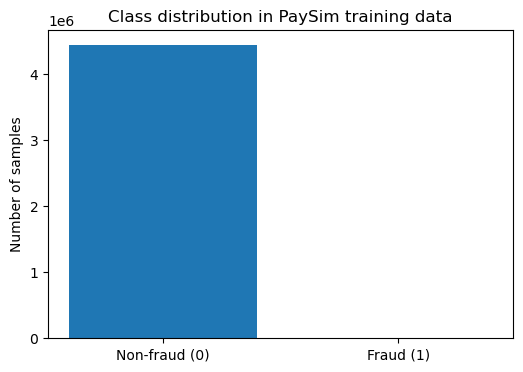

In [44]:
import matplotlib.pyplot as plt

class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Non-fraud (0)", "Fraud (1)"], class_counts.values)
plt.title("Class distribution in PaySim training data")
plt.ylabel("Number of samples")
plt.show()


## Comparison bar chart for the 3 methods

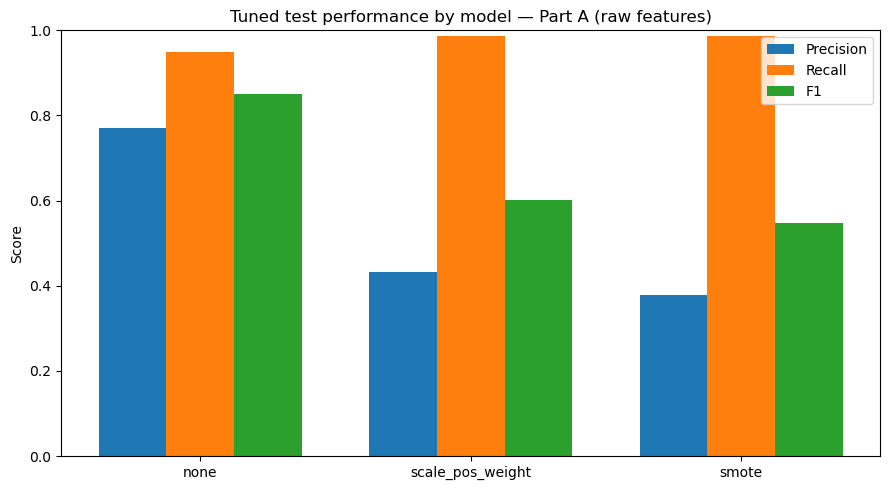

In [45]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["tuned_test_precision", "tuned_test_recall", "tuned_test_f1"]
metric_labels = ["Precision", "Recall", "F1"]

x = np.arange(len(comparison_df["model"]))
width = 0.25

plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, comparison_df[metric], width, label=metric_labels[i])

plt.xticks(x + width, comparison_df["model"])
plt.ylabel("Score")
plt.title("Tuned test performance by model — Part A (raw features)")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


The chart shows that the no-balance XGBoost model has the highest precision and F1-score, while scale_pos_weight and SMOTE have higher recall. This means that imbalance-aware methods detect more fraud cases but create more false positives. Since fraud detection is cost-sensitive, the final choice should be based on expected cost as well as recall, not F1-score alone.

## Expected cost comparison

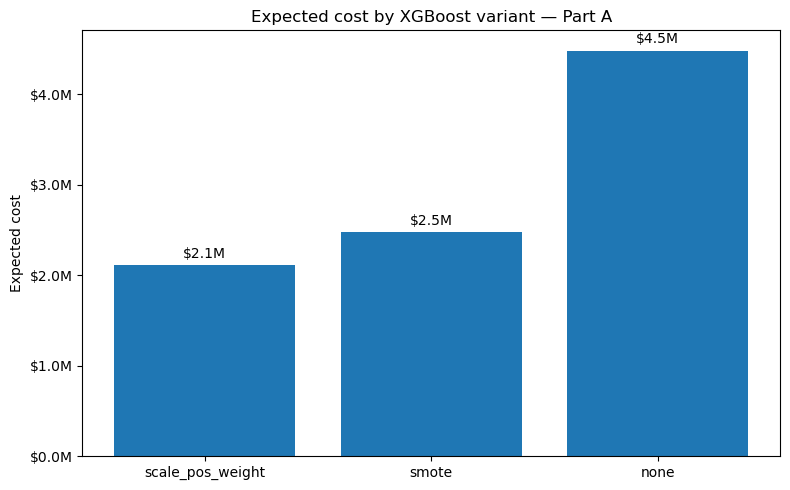

In [46]:
from matplotlib.ticker import FuncFormatter

cost_plot_df = comparison_df.sort_values("tuned_expected_cost")

plt.figure(figsize=(8, 5))
bars = plt.bar(cost_plot_df["model"], cost_plot_df["tuned_expected_cost"])
plt.title("Expected cost by XGBoost variant — Part A")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
plt.bar_label(bars, labels=[f"${v/1_000_000:.1f}M" for v in cost_plot_df["tuned_expected_cost"]], padding=3)
plt.tight_layout()
plt.show()


The chart shows that scale_pos_weight achieves the lowest expected cost among the XGBoost variants, followed by SMOTE. The no-balance model has the highest cost because it misses more fraud cases. Since fraud detection is cost-sensitive, scale_pos_weight is the best XGBoost variant in Part A.

## Threshold performance plot

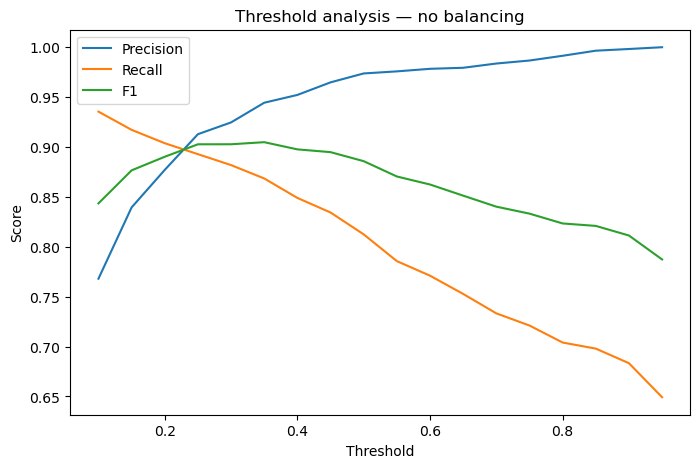

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_none["threshold"], threshold_results_none["precision"], label="Precision")
plt.plot(threshold_results_none["threshold"], threshold_results_none["recall"],    label="Recall")
plt.plot(threshold_results_none["threshold"], threshold_results_none["f1"],        label="F1")
plt.title("Threshold analysis — no balancing")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.legend()
plt.show()


## Tuned confusion matrices

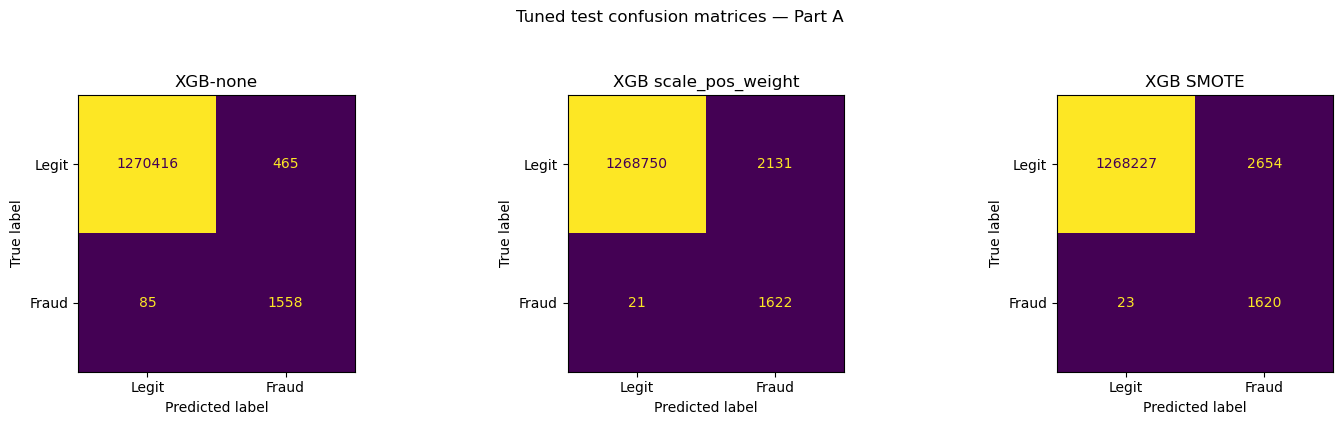

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cm_list = [
    (tuned_cm_none,     "XGB-none"),
    (tuned_cm_weighted, "XGB scale_pos_weight"),
    (tuned_cm_smote,    "XGB SMOTE"),
]
for ax, (cm, title) in zip(axes, cm_list):
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Legit", "Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title)
plt.suptitle("Tuned test confusion matrices — Part A", y=1.05)
plt.tight_layout()
plt.show()


## Threshold analysis — precision, recall, F1

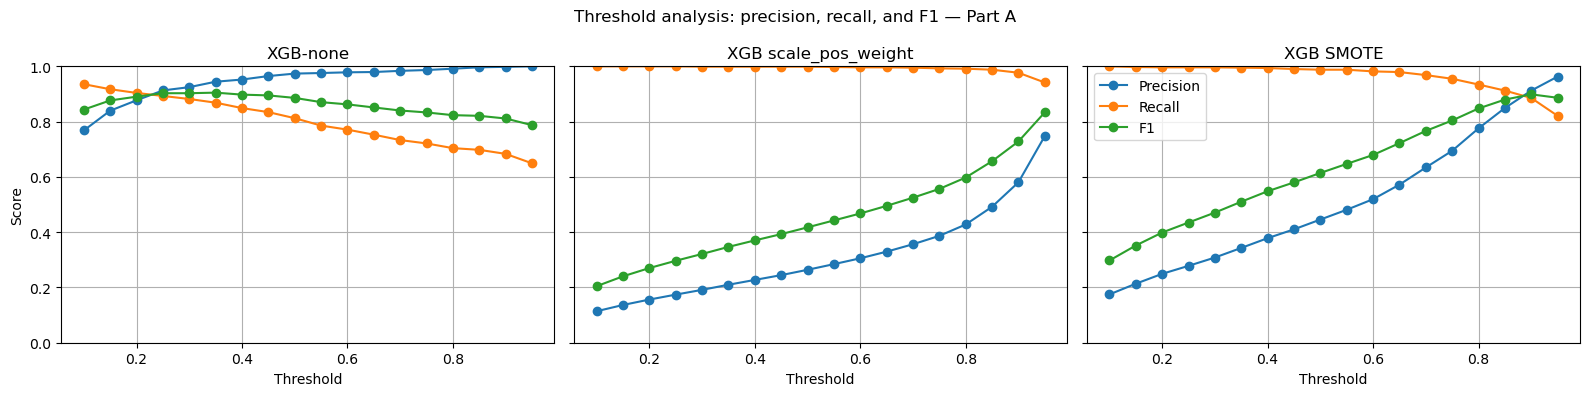

In [49]:
threshold_tables = [
    (threshold_results_none,     "XGB-none"),
    (threshold_results_weighted, "XGB scale_pos_weight"),
    (threshold_results_smote,    "XGB SMOTE"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (df, title) in zip(axes, threshold_tables):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title); ax.set_xlabel("Threshold"); ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score")
axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, and F1 — Part A")
plt.tight_layout()
plt.show()


## Expected cost by threshold

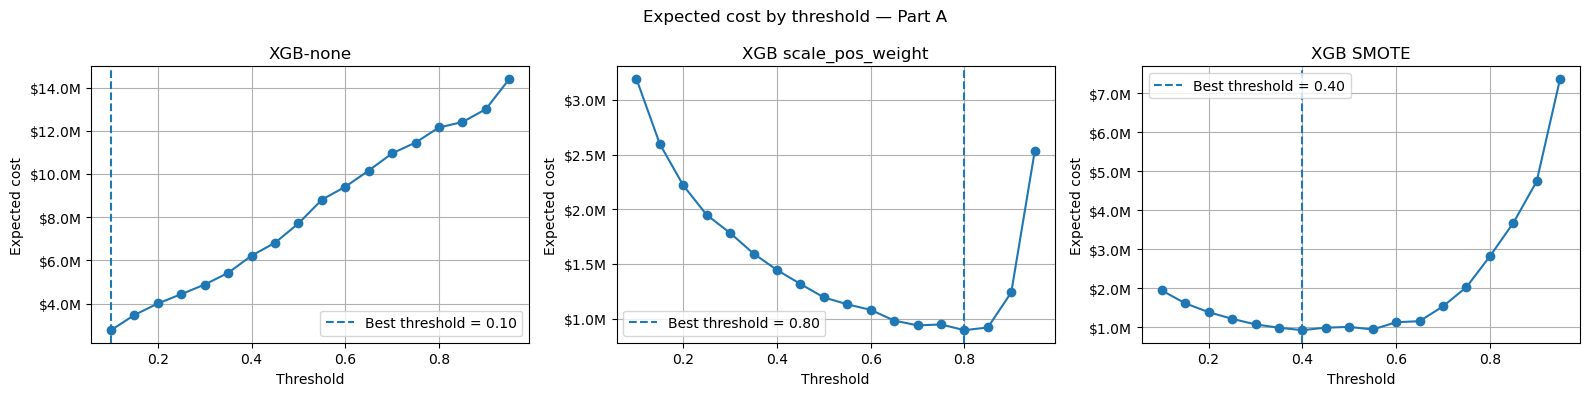

In [50]:
cost_tables = [
    (cost_df_none,     "XGB-none"),
    (cost_df_weighted, "XGB scale_pos_weight"),
    (cost_df_smote,    "XGB SMOTE"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (df, title) in zip(axes, cost_tables):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best threshold = {best_row['threshold']:.2f}")
    ax.set_title(title); ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold — Part A")
plt.tight_layout()
plt.show()


## Precision-Recall curves

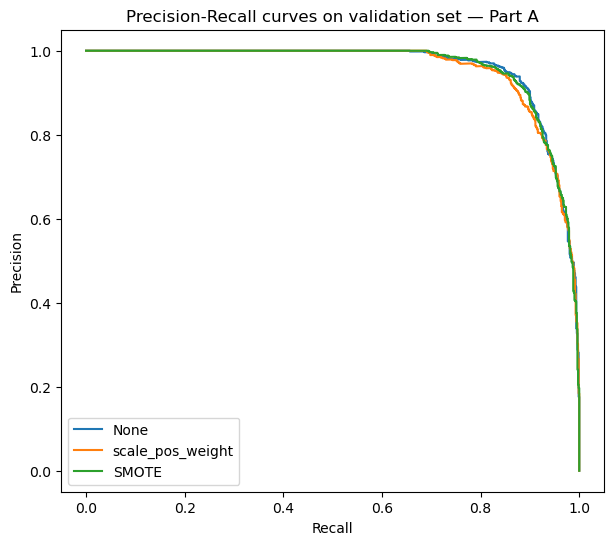

In [51]:
from sklearn.metrics import precision_recall_curve

scores_none = model_none.predict_proba(X_val)[:, 1]
scores_weighted = model_weighted.predict_proba(X_val)[:, 1]
scores_smote = model_smote.predict_proba(X_val)[:, 1]

p_none,     r_none,     _ = precision_recall_curve(y_val, scores_none)
p_weighted, r_weighted, _ = precision_recall_curve(y_val, scores_weighted)
p_smote,    r_smote,    _ = precision_recall_curve(y_val, scores_smote)

plt.figure(figsize=(7, 6))
plt.plot(r_none,     p_none,     label="None")
plt.plot(r_weighted, p_weighted, label="scale_pos_weight")
plt.plot(r_smote,    p_smote,    label="SMOTE")
plt.title("Precision-Recall curves on validation set — Part A")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend()
plt.show()


The precision-recall curves show that all XGBoost variants rank fraud cases very well. The curves are very close, so the difference between the models is small in terms of ranking performance. Therefore, the final choice is better explained by the expected cost comparison, where scale_pos_weight performs best.

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

def plot_model_diagnostics_pretty(cm, threshold_results, cost_df, model_name,
                                   fn_cost=50_000, fp_cost=500, save_path=None):
    cm = np.asarray(cm).astype(int)
    threshold_df   = threshold_results.sort_values("threshold")
    cost_df_sorted = cost_df.sort_values("threshold")
    best_row            = cost_df.loc[cost_df["expected_cost"].idxmin()]
    best_threshold      = float(best_row["threshold"])
    best_validation_cost = float(best_row["expected_cost"])
    tn, fp, fn, tp = cm.ravel()
    test_expected_cost = fn * fn_cost + fp * fp_cost

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    fig.patch.set_facecolor("white")

    # 1. Tuned test confusion matrix
    ax = axes[0]
    cm_for_color = np.maximum(cm, 1)
    norm = LogNorm(vmin=1, vmax=cm_for_color.max())
    im = ax.imshow(cm_for_color, cmap="Blues", norm=norm)
    ax.set_title("Tuned test confusion matrix", fontsize=12, pad=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Legit", "Fraud"]); ax.set_yticklabels(["Legit", "Fraud"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            rgba = im.cmap(norm(cm_for_color[i, j]))
            luminance = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            text_color = "white" if luminance < 0.45 else "#08306b"
            ax.text(j, i, f"{value:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold", color=text_color)
    for spine in ax.spines.values(): spine.set_visible(False)

    # 2. Validation metrics by threshold
    ax = axes[1]
    ax.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2.2, label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"],    linewidth=2.2, label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"],        linewidth=2.2, label="F1")
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.text(0.98, 0.95, f"Best threshold = {best_threshold:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.set_title("Validation metrics by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25); ax.legend(frameon=False, loc="lower left")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    # 3. Validation expected cost by threshold
    ax = axes[2]
    ax.plot(cost_df_sorted["threshold"], cost_df_sorted["expected_cost"],
            linewidth=2.2, marker="o", markersize=4)
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.scatter(best_threshold, best_validation_cost, s=80, color="black", zorder=5)
    ax.annotate(f"Min cost: ${best_validation_cost/1_000_000:.1f}M",
                xy=(best_threshold, best_validation_cost),
                xytext=(18, 18), textcoords="offset points", fontsize=10,
                arrowprops=dict(arrowstyle="->", linewidth=1, color="black"),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title("Validation expected cost by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    fig.suptitle(f"{model_name} diagnostics | Tuned test cost", fontsize=15, fontweight="bold")
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


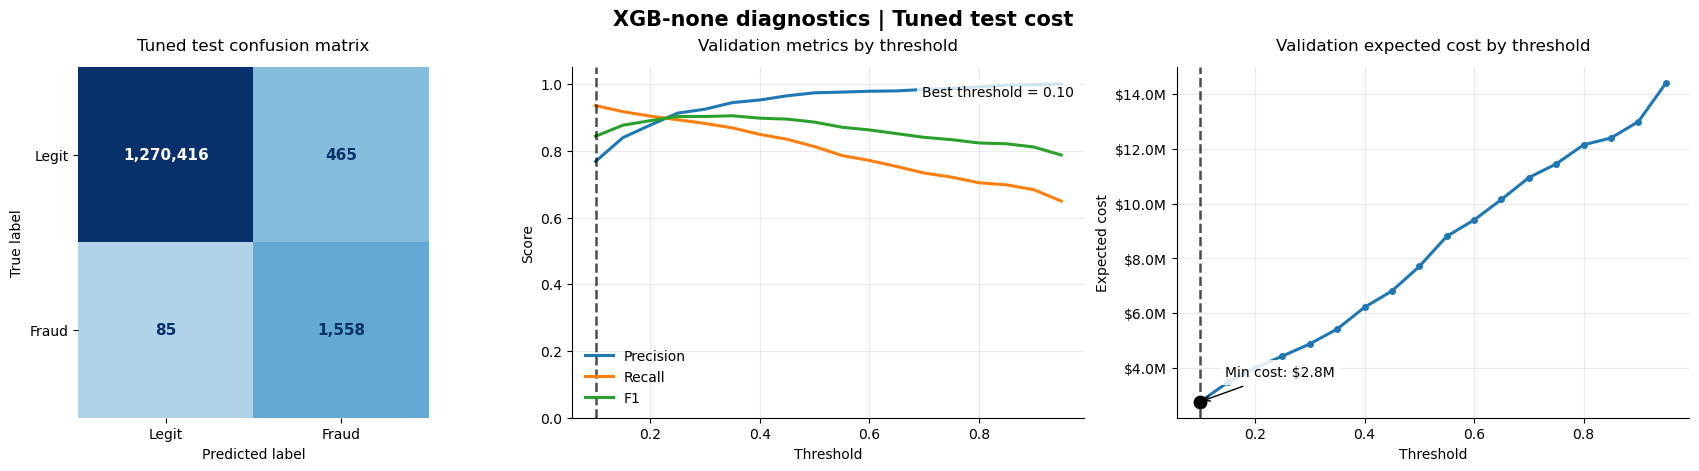

In [53]:
plot_model_diagnostics_pretty(tuned_cm_none, threshold_results_none,
                               cost_df_none, "XGB-none")


The XGB-none diagnostics show that the model performs strongly even without imbalance handling. At the selected threshold of 0.10, it detects 1,558 fraud cases and misses only 85 on the test set. It also produces 465 false positives.

The validation threshold plot shows that lowering the threshold increases recall, while precision remains relatively strong. The cost curve confirms that threshold 0.10 gives the lowest validation cost, because it reduces missed fraud cases.

Overall, XGB-none is much stronger than the Logistic Regression baselines. However, it still misses more fraud cases than the weighted and SMOTE XGBoost models, so its expected cost is higher.

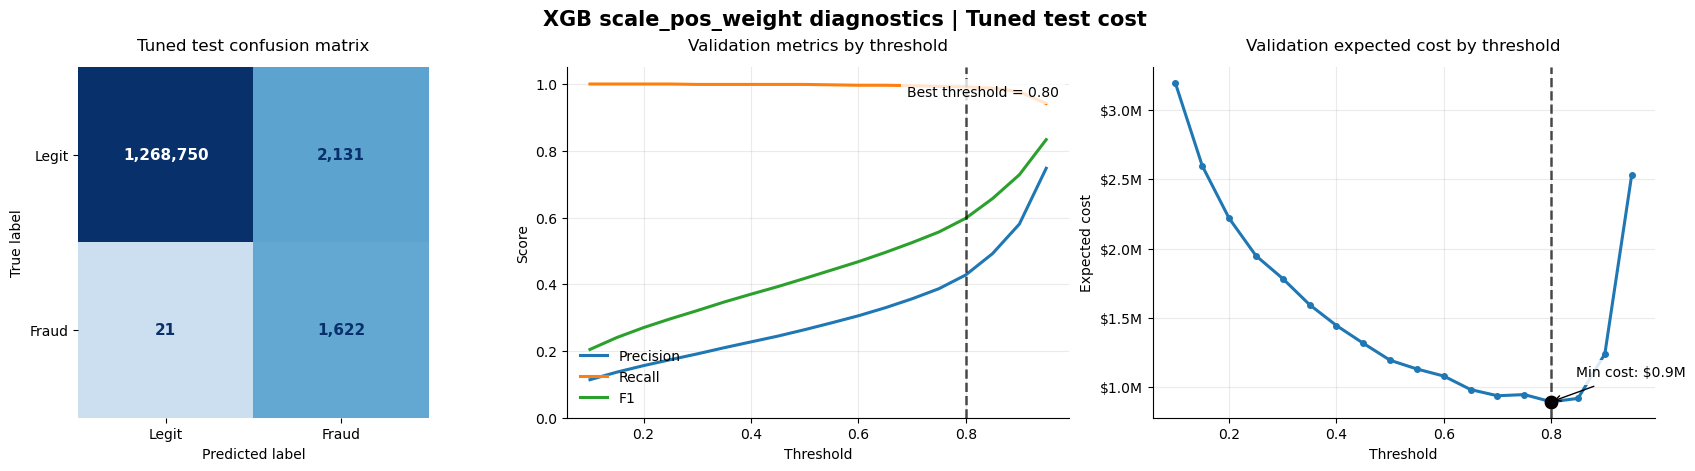

In [54]:
plot_model_diagnostics_pretty(tuned_cm_weighted, threshold_results_weighted,
                               cost_df_weighted, "XGB scale_pos_weight")


The XGB scale_pos_weight diagnostics show that this model is highly effective at detecting fraud. At the selected threshold of 0.80, it detects 1,622 fraud cases on the test set and misses only 21. This is a major reduction in missed fraud compared with XGB-none.

The threshold plot shows that recall stays very high across most thresholds, while precision improves as the threshold increases. The cost curve confirms that threshold 0.80 gives the lowest validation cost. This higher threshold helps reduce false positives while keeping recall extremely high.

Overall, XGB scale_pos_weight gives the best cost-sensitive result in Part A. It misses very few fraud cases and achieves the lowest expected cost among the raw-feature XGBoost variants.

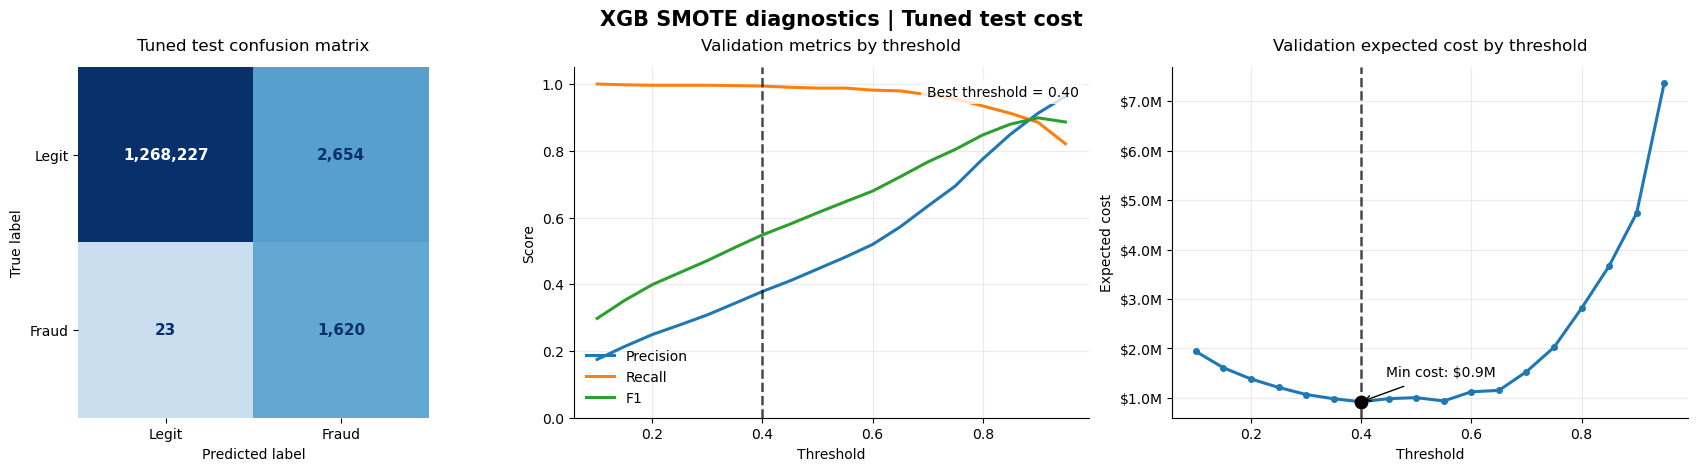

In [55]:
plot_model_diagnostics_pretty(tuned_cm_smote, threshold_results_smote,
                               cost_df_smote, "XGB SMOTE")


The XGB-SMOTE diagnostics show that this model also performs very well. At the selected threshold of 0.40, it detects 1,620 fraud cases on the test set and misses only 23. This is very close to the weighted XGBoost model.

The threshold plot shows that recall stays high across most thresholds, while precision increases as the threshold becomes higher. The cost curve shows that threshold 0.40 gives the lowest validation cost. This threshold keeps recall very high while controlling the number of false positives.

Overall, XGB-SMOTE is a strong model, but its expected cost is slightly higher than XGB scale_pos_weight because it produces more false positives. Therefore, scale_pos_weight remains the best XGBoost variant in Part A.

## Final choice - Part A

Among the raw-feature XGBoost variants, scale_pos_weight achieved the lowest expected cost and was therefore selected as the best Part A model. 

In [56]:
final_a = comparison_df.sort_values("tuned_expected_cost").copy()
final_a


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
1,scale_pos_weight,0.417409,0.999911,0.957481,0.419070,0.999820,0.960959,0.8,0.432188,0.987219,0.601186,2115500
2,smote,0.614161,0.999913,0.960498,0.617973,0.999766,0.962394,0.4,0.379036,0.986001,0.547575,2477000
0,none,0.885790,0.999917,0.961377,0.893185,0.999789,0.963444,0.1,0.770143,0.948265,0.849973,4482500


This result is carried forward for comparison with the Logistic Regression baseline and with the feature-engineered XGBoost variants in Part B.

---
## Part B - With feature engineering

Same three XGBoost variants, but with four additional balance-delta features:

`balance_delta_orig`, 

`balance_delta_dest`, 

`amount_to_balance_ratio`,

`orig_balance_zeroed`. 

These capture anomalies in account balance changes
that raw columns alone do not make explicit.

Part B directly tests whether feature engineering improves XGBoost
on top of the raw-feature baseline established in Part A.


In [57]:
data_fe = prepare_dataframes(paysim_train, paysim_val, paysim_test,
                             use_feature_engineering=True)

X_train_fe = data_fe["X_train"]; y_train_fe = data_fe["y_train"]
X_val_fe   = data_fe["X_val"];   y_val_fe   = data_fe["y_val"]
X_test_fe  = data_fe["X_test"];  y_test_fe  = data_fe["y_test"]

numeric_features_fe     = data_fe["numeric_features"]
categorical_features_fe = data_fe["categorical_features"]
feature_cols_fe         = data_fe["feature_cols"]
spw_fe                  = compute_scale_pos_weight(y_train_fe)

print("Features:", feature_cols_fe)
print("X_train shape:", X_train_fe.shape)
print(f"scale_pos_weight: {spw_fe:.4f}")

for col in ["balance_delta_orig","balance_delta_dest",
            "amount_to_balance_ratio","orig_balance_zeroed"]:
    assert col in X_train_fe.columns, f"Missing: {col}"
print("\nFeature engineering confirmed.")


Features: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'balance_delta_orig', 'balance_delta_dest', 'amount_to_balance_ratio', 'orig_balance_zeroed']
X_train shape: (4453834, 12)
scale_pos_weight: 773.7146

Feature engineering confirmed.


In [58]:
preprocessor_fe = build_preprocessor(numeric_features_fe, categorical_features_fe)
preprocessor_fe


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['step', 'amount', 'oldbalanceOrg',
                                  'newbalanceOrig', 'oldbalanceDest',
                                  'newbalanceDest', 'isFlaggedFraud',
                                  'balance_delta_orig', 'balance_delta_dest',
                                  'amount_to_balance_ratio',
                                  'orig_balance_zeroed']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['type'])])

## 5. XGBoost with feature engineering - no imbalance handling

Identical to experiment 1 (A.1) but with engineered features.
Isolates the effect of feature engineering from imbalance handling.


In [59]:
results_dir = results_root / "xgb_fe_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "fe_none_model.joblib"
FORCE_RETRAIN = False

print("Results dir:", results_dir)
print("Model path:", model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved XGB-FE-none model...")
    model_fe_none = joblib.load(model_path)
    print("Model loaded.")
else:
    print("Training XGB-FE-none...")
    preprocessor = build_preprocessor(numeric_features_fe, categorical_features_fe)
    model_fe_none = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method="none",
        scale_pos_weight=spw_fe,
    )
    model_fe_none = fit_model(model_fe_none, X_train_fe, y_train_fe,
                               eval_set=(X_val_fe, y_val_fe))
    joblib.dump(model_fe_none, model_path)
    print("Training finished. Model saved to:", model_path)


Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_fe_none
Model path: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_fe_none\fe_none_model.joblib
Model exists: True
Already trained. Loading saved XGB-FE-none model...
Model loaded.


In [60]:
val_metrics_fe_none, val_cm_fe_none = evaluate_model(
    model_fe_none, X_val_fe, y_val_fe, split_name="validation_fe_none")
test_metrics_fe_none, test_cm_fe_none = evaluate_model(
    model_fe_none, X_test_fe, y_test_fe, split_name="test_fe_none")



=== VALIDATION_FE_NONE ===
  accuracy: 0.999852
  precision: 0.952677
  recall: 0.931790
  f1: 0.942118
  roc_auc: 0.999987
  pr_auc: 0.990648

Confusion matrix:
 [[635403     38]
 [    56    765]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999    635441
           1     0.9527    0.9318    0.9421       821

    accuracy                         0.9999    636262
   macro avg     0.9763    0.9659    0.9710    636262
weighted avg     0.9999    0.9999    0.9999    636262


=== TEST_FE_NONE ===
  accuracy: 0.999870
  precision: 0.958437
  recall: 0.940353
  f1: 0.949309
  roc_auc: 0.999565
  pr_auc: 0.991117

Confusion matrix:
 [[1270814      67]
 [     98    1545]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999   1270881
           1     0.9584    0.9404    0.9493      1643

    accuracy                         0.9999   1272524
   macro av

### Interpretation of the XGBoost feature-engineered baseline without imbalance handling

The feature-engineered XGBoost model without imbalance handling performs extremely well. Compared with the raw-feature XGBoost model, the feature-engineered version improves both recall and F1-score while keeping precision very high.

On the validation set, the model achieves a precision of 0.9527, recall of 0.9318, and F1-score of 0.9421. The test results are very similar, which suggests that the model generalizes well. On the test set, precision is 0.9584, recall is 0.9404, and F1-score is 0.9493.

The confusion matrix shows that the model correctly detects 1,545 out of 1,643 fraud cases and misses only 98. It also produces only 67 false positives, meaning that very few legitimate transactions are incorrectly flagged as fraud.

The ranking metrics are also very strong. The test ROC-AUC is 0.9996 and the test PR-AUC is 0.9911. This is a major improvement over the raw-feature XGBoost baseline and shows that the engineered features help the model separate fraudulent and legitimate transactions more effectively.



In [61]:
threshold_results_fe_none = search_thresholds(model_fe_none, X_val_fe, y_val_fe)
print(threshold_results_fe_none)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.829615  0.996346  0.905368              986
1        0.15   0.846154  0.991474  0.913068              962
2        0.20   0.874595  0.985384  0.926690              925
3        0.25   0.894327  0.979294  0.934884              899
4        0.30   0.909300  0.964677  0.936170              871
5        0.35   0.924528  0.954933  0.939485              848
6        0.40   0.934132  0.950061  0.942029              835
7        0.45   0.944988  0.941535  0.943258              818
8        0.50   0.952677  0.931790  0.942118              803
9        0.55   0.960759  0.924482  0.942272              790
10       0.60   0.965429  0.918392  0.941323              781
11       0.65   0.973890  0.908648  0.940139              766
12       0.70   0.974934  0.900122  0.936035              758
13       0.75   0.981107  0.885505  0.930858              741
14       0.80   0.983562  0.874543  0.925854              730
15      

In [62]:
cost_df_fe_none = compute_cost_table(threshold_results_fe_none, y_val_fe)
print(cost_df_fe_none.head())


   threshold   tp   fp  fn      tn  precision    recall        f1  \
0       0.10  818  168   3  635273   0.829615  0.996346  0.905368   
1       0.15  814  148   7  635293   0.846154  0.991474  0.913068   
2       0.20  809  116  12  635325   0.874595  0.985384  0.926690   
3       0.25  804   95  17  635346   0.894327  0.979294  0.934884   
4       0.30  792   79  29  635362   0.909300  0.964677  0.936170   

   predicted_fraud  expected_cost  
0              986         234000  
1              962         424000  
2              925         658000  
3              899         897500  
4              871        1489500  


Threshold tuning was applied to the feature-engineered XGBoost model without imbalance handling. The results show that the model performs very well across a wide range of thresholds, with both precision and recall staying high.

The cost table shows that the best threshold is 0.10. At this threshold, the model detects 818 fraud cases on the validation set and misses only 3. It also produces 168 false positives. This gives the lowest validation expected cost of $234,000.

At threshold 0.10, recall is extremely high at 0.9963, while precision remains strong at 0.8296. This is a very good cost-sensitive trade-off because the model catches almost all fraud cases while keeping false positives relatively low.

The expected validation cost at threshold 0.10 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 3 × $50,000 + 168 × $500  
Expected cost = $150,000 + $84,000  
Expected cost = $234,000

The engineered features make the XGBoost model much stronger. 

### Threshold tuning - B.1

In [63]:
best_threshold_fe_none = float(cost_df_fe_none.iloc[0]["threshold"])
print("Best threshold:", best_threshold_fe_none)


Best threshold: 0.1


In [64]:
tuned_metrics_fe_none, tuned_cm_fe_none = evaluate_with_threshold(
    model_fe_none, X_test_fe, y_test_fe, best_threshold_fe_none)
cost_summary_fe_none = compute_expected_cost_from_cm(tuned_cm_fe_none)
print(cost_summary_fe_none)



Tuned threshold : 0.1
  Precision     : 0.843026
  Recall        : 0.996957
  F1            : 0.913553

Confusion matrix:
 [[1270576     305]
 [      5    1638]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9998    0.9999   1270881
           1     0.8430    0.9970    0.9136      1643

    accuracy                         0.9998   1272524
   macro avg     0.9215    0.9984    0.9567   1272524
weighted avg     0.9998    0.9998    0.9998   1272524

{'tp': 1638, 'fp': 305, 'fn': 5, 'tn': 1270576, 'expected_cost': 402500}


After threshold tuning, the selected threshold for the feature-engineered XGBoost baseline was 0.10. This threshold was chosen because it gave the lowest expected cost on the validation set.

On the test set, the tuned model achieved a precision of 0.8430, recall of 0.9970, and F1-score of 0.9136. This means that the model detects almost all fraud cases, while most predicted fraud cases are also correct.

The confusion matrix shows very strong performance. The model correctly detects 1,638 out of 1,643 fraud cases and misses only 5. It also produces 305 false positives. This is a very strong trade-off because false negatives are much more expensive than false positives.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 5 × $50,000 + 305 × $500  
Expected cost = $250,000 + $152,500  
Expected cost = $402,500

Thee feature-engineered XGBoost baseline performs extremely well after threshold tuning. It detects almost every fraud case, keeps false positives relatively low, and achieves a much lower expected cost than the raw-feature XGBoost models.

In [65]:
save_experiment_outputs(
    results_dir=results_dir, model=model_fe_none,
    val_metrics=val_metrics_fe_none, test_metrics=test_metrics_fe_none,
    val_cm=val_cm_fe_none, test_cm=test_cm_fe_none,
    threshold_results=threshold_results_fe_none, cost_df=cost_df_fe_none,
    tuned_metrics=tuned_metrics_fe_none, tuned_cm=tuned_cm_fe_none,
    prefix="fe_none",
)
print("Saved outputs to:", results_dir)


Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_fe_none


In [66]:
saved_files = sorted([p.name for p in results_dir.glob('*')])
saved_files

['fe_none_cost_results.csv',
 'fe_none_metrics_summary.csv',
 'fe_none_model.joblib',
 'fe_none_test_confusion_matrix.csv',
 'fe_none_test_metrics.json',
 'fe_none_threshold_results.csv',
 'fe_none_tuned_test_confusion_matrix.csv',
 'fe_none_tuned_test_metrics.json',
 'fe_none_validation_confusion_matrix.csv',
 'fe_none_validation_metrics.json']

## 6. XGBoost with feature engineering - scale_pos_weight

In [67]:
results_dir = results_root / "xgb_fe_weighted"
results_dir.mkdir(parents=True, exist_ok=True)
model_path    = results_dir / "fe_weighted_model.joblib"
FORCE_RETRAIN = False

print("Results dir:", results_dir); print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading..."); model_fe_weighted = joblib.load(model_path)
else:
    print("Training XGB-FE-weighted...")
    preprocessor = build_preprocessor(numeric_features_fe, categorical_features_fe)
    model_fe_weighted = build_xgb_pipeline(
        preprocessor=preprocessor, imbalance_method="scale_pos_weight",
        scale_pos_weight=spw_fe)
    model_fe_weighted = fit_model(model_fe_weighted, X_train_fe, y_train_fe,
                                   eval_set=(X_val_fe, y_val_fe))
    joblib.dump(model_fe_weighted, model_path)
    print("Saved to:", model_path)


Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_fe_weighted
Model exists: True
Already trained. Loading...


In [68]:
val_metrics_fe_weighted, val_cm_fe_weighted = evaluate_model(
    model_fe_weighted, X_val_fe, y_val_fe, split_name="validation_fe_weighted")
test_metrics_fe_weighted, test_cm_fe_weighted = evaluate_model(
    model_fe_weighted, X_test_fe, y_test_fe, split_name="test_fe_weighted")



=== VALIDATION_FE_WEIGHTED ===
  accuracy: 0.999709
  precision: 0.816733
  recall: 0.998782
  f1: 0.898630
  roc_auc: 0.999986
  pr_auc: 0.989167

Confusion matrix:
 [[635257    184]
 [     1    820]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999    635441
           1     0.8167    0.9988    0.8986       821

    accuracy                         0.9997    636262
   macro avg     0.9084    0.9992    0.9492    636262
weighted avg     0.9998    0.9997    0.9997    636262


=== TEST_FE_WEIGHTED ===
  accuracy: 0.999723
  precision: 0.824447
  recall: 0.997565
  f1: 0.902782
  roc_auc: 0.999532
  pr_auc: 0.989821

Confusion matrix:
 [[1270532     349]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999   1270881
           1     0.8244    0.9976    0.9028      1643

    accuracy                         0.9997   1272524
   

### Interpretation of the feature-engineered weighted XGBoost model

The feature-engineered weighted XGBoost model performs extremely well. By combining engineered features with `scale_pos_weight`, the model becomes highly sensitive to fraud while still keeping precision strong.

On the validation set, the model achieves a precision of 0.8167, recall of 0.9988, and F1-score of 0.8986. The test results are very similar, which shows stable generalization. On the test set, precision is 0.8244, recall is 0.9976, and F1-score is 0.9028.

The confusion matrix shows that the model correctly detects 1,639 out of 1,643 fraud cases and misses only 4. It also produces 349 false positives. This means that the model catches almost every fraud case, although it flags slightly more legitimate transactions than the feature-engineered no-balance model.

The ranking metrics are also very strong. The test ROC-AUC is 0.9995 and the test PR-AUC is 0.9898. This confirms that the model separates fraudulent and legitimate transactions very well.


In [69]:
threshold_results_fe_weighted = search_thresholds(model_fe_weighted, X_val_fe, y_val_fe)
print(threshold_results_fe_weighted.head())


   threshold  precision    recall        f1  predicted_fraud
0       0.10   0.778199  1.000000  0.875267             1055
1       0.15   0.790183  1.000000  0.882796             1039
2       0.20   0.798442  0.998782  0.887446             1027
3       0.25   0.801564  0.998782  0.889371             1023
4       0.30   0.803134  0.998782  0.890337             1021


In [70]:
cost_df_fe_weighted = compute_cost_table(threshold_results_fe_weighted, y_val_fe)
print(cost_df_fe_weighted.head())


   threshold   tp   fp  fn      tn  precision    recall        f1  \
0       0.15  821  218   0  635223   0.790183  1.000000  0.882796   
1       0.10  821  234   0  635207   0.778199  1.000000  0.875267   
2       0.85  820  175   1  635266   0.824121  0.998782  0.903084   
3       0.80  820  176   1  635265   0.823293  0.998782  0.902587   
4       0.75  820  177   1  635264   0.822467  0.998782  0.902090   

   predicted_fraud  expected_cost  
0             1039         109000  
1             1055         117000  
2              995         137500  
3              996         138000  
4              997         138500  


Threshold tuning was applied to the feature-engineered weighted XGBoost model. This model already has extremely high recall, so the goal of tuning is to keep missed fraud cases as low as possible while controlling false positives.

The cost table shows that the best threshold is 0.15. At this threshold, the model detects all 821 fraud cases on the validation set and misses none. It produces 218 false positives, giving the lowest validation expected cost of $109,000.

At threshold 0.15, recall is 1.0000 and precision is 0.7902. This means that the model catches every fraud case in the validation set, while most predicted fraud cases are still correct.

The expected validation cost at threshold 0.15 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 218 × $500  
Expected cost = $109,000

Threshold 0.15 gives the best cost-sensitive trade-off for the feature-engineered weighted XGBoost model. 

In [71]:
best_threshold_fe_weighted = float(cost_df_fe_weighted.iloc[0]["threshold"])
print("Best threshold:", best_threshold_fe_weighted)


Best threshold: 0.15000000000000002


In [72]:
tuned_metrics_fe_weighted, tuned_cm_fe_weighted = evaluate_with_threshold(
    model_fe_weighted, X_test_fe, y_test_fe, best_threshold_fe_weighted)
cost_summary_fe_weighted = compute_expected_cost_from_cm(tuned_cm_fe_weighted)
print(cost_summary_fe_weighted)



Tuned threshold : 0.15000000000000002
  Precision     : 0.787224
  Recall        : 0.997565
  F1            : 0.880000

Confusion matrix:
 [[1270438     443]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9998   1270881
           1     0.7872    0.9976    0.8800      1643

    accuracy                         0.9996   1272524
   macro avg     0.8936    0.9986    0.9399   1272524
weighted avg     0.9997    0.9996    0.9997   1272524

{'tp': 1639, 'fp': 443, 'fn': 4, 'tn': 1270438, 'expected_cost': 421500}


After threshold tuning, the selected threshold for the feature-engineered weighted XGBoost model was 0.15. This threshold was chosen because it gave the lowest expected cost on the validation set.

On the test set, the tuned model achieved a precision of 0.7872, recall of 0.9976, and F1-score of 0.8800. This means that the model detects almost all fraud cases, but it also produces more false positives than the feature-engineered no-balance model.

The confusion matrix shows that the model correctly detects 1,639 out of 1,643 fraud cases and misses only 4. It also produces 443 false positives. Since false negatives are much more expensive than false positives, this is still a strong cost-sensitive result.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 4 × $50,000 + 443 × $500  
Expected cost = $200,000 + $221,500  
Expected cost = $421,500

In [73]:
save_experiment_outputs(
    results_dir=results_dir, model=model_fe_weighted,
    val_metrics=val_metrics_fe_weighted, test_metrics=test_metrics_fe_weighted,
    val_cm=val_cm_fe_weighted, test_cm=test_cm_fe_weighted,
    threshold_results=threshold_results_fe_weighted, cost_df=cost_df_fe_weighted,
    tuned_metrics=tuned_metrics_fe_weighted, tuned_cm=tuned_cm_fe_weighted,
    prefix="fe_weighted",
)
print("Saved outputs to:", results_dir)


Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_fe_weighted


In [74]:
saved_files = sorted([p.name for p in results_dir.glob('*')])
saved_files

['fe_weighted_cost_results.csv',
 'fe_weighted_metrics_summary.csv',
 'fe_weighted_model.joblib',
 'fe_weighted_test_confusion_matrix.csv',
 'fe_weighted_test_metrics.json',
 'fe_weighted_threshold_results.csv',
 'fe_weighted_tuned_test_confusion_matrix.csv',
 'fe_weighted_tuned_test_metrics.json',
 'fe_weighted_validation_confusion_matrix.csv',
 'fe_weighted_validation_metrics.json']

## 7. XGBoost with feature engineering - SMOTE (strategy=0.1)

In [75]:
results_dir = results_root / "xgb_fe_smote"
results_dir.mkdir(parents=True, exist_ok=True)
model_path    = results_dir / "fe_smote_model.joblib"
FORCE_RETRAIN = False

print("Results dir:", results_dir); print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading..."); model_fe_smote = joblib.load(model_path)
else:
    print("Training XGB-FE-SMOTE...")
    preprocessor = build_preprocessor(numeric_features_fe, categorical_features_fe)
    model_fe_smote = build_xgb_pipeline(
        preprocessor=preprocessor, imbalance_method="smote",
        scale_pos_weight=spw_fe, smote_sampling_strategy=0.1)
    model_fe_smote = fit_model(model_fe_smote, X_train_fe, y_train_fe,
                                eval_set=(X_val_fe, y_val_fe))
    joblib.dump(model_fe_smote, model_path)
    print("Saved to:", model_path)


Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_fe_smote
Model exists: True
Already trained. Loading...


In [76]:
val_metrics_fe_smote, val_cm_fe_smote = evaluate_model(
    model_fe_smote, X_val_fe, y_val_fe, split_name="validation_fe_smote")
test_metrics_fe_smote, test_cm_fe_smote = evaluate_model(
    model_fe_smote, X_test_fe, y_test_fe, split_name="test_fe_smote")



=== VALIDATION_FE_SMOTE ===
  accuracy: 0.999976
  precision: 0.982057
  recall: 1.000000
  f1: 0.990947
  roc_auc: 1.000000
  pr_auc: 1.000000

Confusion matrix:
 [[635426     15]
 [     0    821]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    635441
           1     0.9821    1.0000    0.9909       821

    accuracy                         1.0000    636262
   macro avg     0.9910    1.0000    0.9955    636262
weighted avg     1.0000    1.0000    1.0000    636262


=== TEST_FE_SMOTE ===
  accuracy: 0.999976
  precision: 0.983794
  recall: 0.997565
  f1: 0.990632
  roc_auc: 0.999756
  pr_auc: 0.998648

Confusion matrix:
 [[1270854      27]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9838    0.9976    0.9906      1643

    accuracy                         1.0000   1272524
   macro 

### Interpretation of the feature-engineered XGBoost-SMOTE model

The feature-engineered XGBoost-SMOTE model gives the strongest results so far. It combines engineered features with SMOTE, which helps the model detect fraud extremely well while keeping false positives very low.

On the validation set, the model achieves perfect recall of 1.0000, meaning that it detects all fraud cases. It also has very high precision of 0.9821 and an F1-score of 0.9909.

The test results are also extremely strong. The model achieves precision of 0.9838, recall of 0.9976, and F1-score of 0.9906. This means that the model detects almost all fraud cases and most of its fraud predictions are correct.

The confusion matrix confirms this. On the test set, the model correctly detects 1,639 out of 1,643 fraud cases and misses only 4. It also produces only 27 false positives. This is a major improvement compared with the other feature-engineered variants.

The ranking metrics are also almost perfect. The test ROC-AUC is 0.9998 and the test PR-AUC is 0.9986. This shows that the model separates fraudulent and legitimate transactions extremely well.


In [77]:
threshold_results_fe_smote = search_thresholds(model_fe_smote, X_val_fe, y_val_fe)
print(threshold_results_fe_smote.head())


   threshold  precision  recall        f1  predicted_fraud
0       0.10   0.935080     1.0  0.966451              878
1       0.15   0.943678     1.0  0.971023              870
2       0.20   0.952436     1.0  0.975639              862
3       0.25   0.957993     1.0  0.978546              857
4       0.30   0.967020     1.0  0.983234              849


In [78]:
cost_df_fe_smote = compute_cost_table(threshold_results_fe_smote, y_val_fe)
print(cost_df_fe_smote.head())


   threshold   tp  fp  fn      tn  precision  recall        f1  \
0       0.95  821   0   0  635441   1.000000     1.0  1.000000   
1       0.85  821   1   0  635440   0.998783     1.0  0.999391   
2       0.80  821   1   0  635440   0.998783     1.0  0.999391   
3       0.75  821   1   0  635440   0.998783     1.0  0.999391   
4       0.90  821   1   0  635440   0.998783     1.0  0.999391   

   predicted_fraud  expected_cost  
0              821              0  
1              822            500  
2              822            500  
3              822            500  
4              822            500  


Threshold tuning was applied to the feature-engineered XGBoost-SMOTE model. This model already performs extremely well across the tested thresholds. Even at low thresholds, recall remains 1.0000, meaning that the model detects all fraud cases in the validation set.

The cost table shows that the best threshold is 0.95. At this threshold, the model detects all 821 fraud cases, produces no false positives, and misses no fraud cases on the validation set. This gives an expected validation cost of $0.

At threshold 0.95, both precision and recall are 1.0000. This means that every predicted fraud case is correct, and every actual fraud case is detected.

The expected validation cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 0 × $50,000 + 0 × $500  
Expected cost = $0


In [79]:
best_threshold_fe_smote = float(cost_df_fe_smote.iloc[0]["threshold"])
print("Best threshold:", best_threshold_fe_smote)


Best threshold: 0.9500000000000003


In [80]:
tuned_metrics_fe_smote, tuned_cm_fe_smote = evaluate_with_threshold(
    model_fe_smote, X_test_fe, y_test_fe, best_threshold_fe_smote)
cost_summary_fe_smote = compute_expected_cost_from_cm(tuned_cm_fe_smote)
print(cost_summary_fe_smote)



Tuned threshold : 0.9500000000000003
  Precision     : 1.000000
  Recall        : 0.997565
  F1            : 0.998781

Confusion matrix:
 [[1270881       0]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     1.0000    0.9976    0.9988      1643

    accuracy                         1.0000   1272524
   macro avg     1.0000    0.9988    0.9994   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

{'tp': 1639, 'fp': 0, 'fn': 4, 'tn': 1270881, 'expected_cost': 200000}


### Tuned threshold results for the feature-engineered XGBoost-SMOTE model

After threshold tuning, the selected threshold for the feature-engineered XGBoost-SMOTE model was 0.95. This threshold was chosen because it gave the lowest expected cost on the validation set.

On the test set, the tuned model achieved almost perfect performance. Precision is 1.0000, recall is 0.9976, and F1-score is 0.9988. This means that every transaction predicted as fraud was actually fraud, and the model missed only a very small number of fraud cases.

The confusion matrix shows that the model correctly detected 1,639 out of 1,643 fraud cases and missed only 4. It produced 0 false positives, meaning that no legitimate transactions were incorrectly flagged as fraud.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 4 × $50,000 + 0 × $500  
Expected cost = $200,000

This is the lowest expected cost so far. The result shows that combining feature engineering with SMOTE gives a very strong fraud detection model.


In [81]:
save_experiment_outputs(
    results_dir=results_dir, model=model_fe_smote,
    val_metrics=val_metrics_fe_smote, test_metrics=test_metrics_fe_smote,
    val_cm=val_cm_fe_smote, test_cm=test_cm_fe_smote,
    threshold_results=threshold_results_fe_smote, cost_df=cost_df_fe_smote,
    tuned_metrics=tuned_metrics_fe_smote, tuned_cm=tuned_cm_fe_smote,
    prefix="fe_smote",
)
print("Saved outputs to:", results_dir)


Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_fe_smote


In [82]:
saved_files = sorted([p.name for p in results_dir.glob('*')])
saved_files

['fe_smote_cost_results.csv',
 'fe_smote_metrics_summary.csv',
 'fe_smote_model.joblib',
 'fe_smote_test_confusion_matrix.csv',
 'fe_smote_test_metrics.json',
 'fe_smote_threshold_results.csv',
 'fe_smote_tuned_test_confusion_matrix.csv',
 'fe_smote_tuned_test_metrics.json',
 'fe_smote_validation_confusion_matrix.csv',
 'fe_smote_validation_metrics.json']

## 8. Comparison - Part B (with feature engineering)

In [83]:
comparison_fe_df = pd.DataFrame([
    {"model":"fe_none",
     "val_f1":val_metrics_fe_none["f1"],"val_roc_auc":val_metrics_fe_none["roc_auc"],
     "val_pr_auc":val_metrics_fe_none["pr_auc"],"test_f1":test_metrics_fe_none["f1"],
     "test_roc_auc":test_metrics_fe_none["roc_auc"],"test_pr_auc":test_metrics_fe_none["pr_auc"],
     "best_threshold":best_threshold_fe_none,
     "tuned_test_precision":tuned_metrics_fe_none["precision"],
     "tuned_test_recall":tuned_metrics_fe_none["recall"],
     "tuned_test_f1":tuned_metrics_fe_none["f1"],
     "tuned_expected_cost":cost_summary_fe_none["expected_cost"]},
    {"model":"fe_weighted",
     "val_f1":val_metrics_fe_weighted["f1"],"val_roc_auc":val_metrics_fe_weighted["roc_auc"],
     "val_pr_auc":val_metrics_fe_weighted["pr_auc"],"test_f1":test_metrics_fe_weighted["f1"],
     "test_roc_auc":test_metrics_fe_weighted["roc_auc"],"test_pr_auc":test_metrics_fe_weighted["pr_auc"],
     "best_threshold":best_threshold_fe_weighted,
     "tuned_test_precision":tuned_metrics_fe_weighted["precision"],
     "tuned_test_recall":tuned_metrics_fe_weighted["recall"],
     "tuned_test_f1":tuned_metrics_fe_weighted["f1"],
     "tuned_expected_cost":cost_summary_fe_weighted["expected_cost"]},
    {"model":"fe_smote",
     "val_f1":val_metrics_fe_smote["f1"],"val_roc_auc":val_metrics_fe_smote["roc_auc"],
     "val_pr_auc":val_metrics_fe_smote["pr_auc"],"test_f1":test_metrics_fe_smote["f1"],
     "test_roc_auc":test_metrics_fe_smote["roc_auc"],"test_pr_auc":test_metrics_fe_smote["pr_auc"],
     "best_threshold":best_threshold_fe_smote,
     "tuned_test_precision":tuned_metrics_fe_smote["precision"],
     "tuned_test_recall":tuned_metrics_fe_smote["recall"],
     "tuned_test_f1":tuned_metrics_fe_smote["f1"],
     "tuned_expected_cost":cost_summary_fe_smote["expected_cost"]},
])
print(comparison_fe_df)


         model    val_f1  val_roc_auc  val_pr_auc   test_f1  test_roc_auc  \
0      fe_none  0.942118     0.999987    0.990648  0.949309      0.999565   
1  fe_weighted  0.898630     0.999986    0.989167  0.902782      0.999532   
2     fe_smote  0.990947     1.000000    1.000000  0.990632      0.999756   

   test_pr_auc  best_threshold  tuned_test_precision  tuned_test_recall  \
0     0.991117            0.10              0.843026           0.996957   
1     0.989821            0.15              0.787224           0.997565   
2     0.998648            0.95              1.000000           0.997565   

   tuned_test_f1  tuned_expected_cost  
0       0.913553               402500  
1       0.880000               421500  
2       0.998781               200000  


In [84]:
comparison_fe_df.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
2,fe_smote,0.95,1.000000,0.997565,0.998781,200000
0,fe_none,0.10,0.843026,0.996957,0.913553,402500
1,fe_weighted,0.15,0.787224,0.997565,0.880000,421500


Among the feature-engineered XGBoost variants, SMOTE achieved the strongest performance. It reached the highest test PR-AUC of 0.9986, the highest tuned F1-score of 0.9988, and the lowest expected cost of $200,000. The model produced no false positives and missed only 4 fraud cases on the test set. Therefore, feature-engineered XGBoost with SMOTE was selected as the best Part B model. 
However, because the performance is almost perfect, the engineered features should be checked carefully for possible data leakage.

## Comparison bar chart - Part B

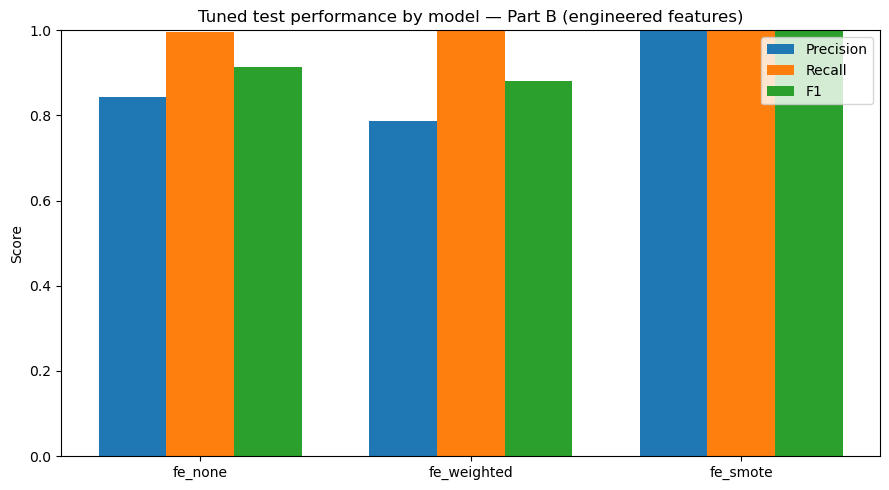

In [85]:
x = np.arange(len(comparison_fe_df["model"])); width = 0.25
plt.figure(figsize=(9, 5))
for i, (metric, lbl) in enumerate([("tuned_test_precision","Precision"),
                                    ("tuned_test_recall","Recall"),
                                    ("tuned_test_f1","F1")]):
    plt.bar(x + i*width, comparison_fe_df[metric], width, label=lbl)
plt.xticks(x + width, comparison_fe_df["model"]); plt.ylabel("Score")
plt.title("Tuned test performance by model — Part B (engineered features)")
plt.legend(); plt.ylim(0, 1); plt.tight_layout(); plt.show()


The chart shows that all feature-engineered XGBoost models perform very well, especially in recall. However, `fe_smote` gives the best overall result: it has perfect precision, very high recall, and the highest F1-score. This means it detects almost all fraud cases while producing no false positives on the test set.

## Expected cost comparison - Part B

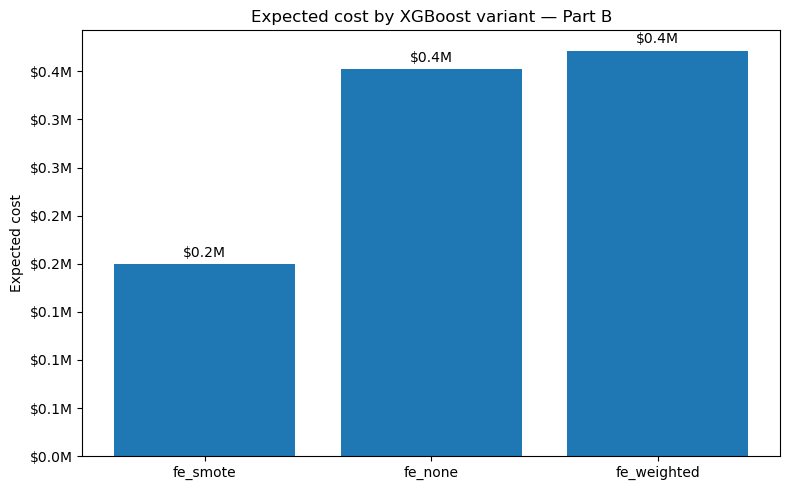

In [86]:
cost_plot_fe = comparison_fe_df.sort_values("tuned_expected_cost")
plt.figure(figsize=(8, 5))
bars = plt.bar(cost_plot_fe["model"], cost_plot_fe["tuned_expected_cost"])
plt.title("Expected cost by XGBoost variant — Part B")
plt.ylabel("Expected cost")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
plt.bar_label(bars, labels=[f"${v/1_000_000:.1f}M" for v in cost_plot_fe["tuned_expected_cost"]], padding=3)
plt.tight_layout(); plt.show()


The chart shows that `fe_smote` achieves the lowest expected cost among the feature-engineered XGBoost variants. It clearly outperforms `fe_none` and `fe_weighted`, mainly because it produces no false positives and misses only 4 fraud cases. Therefore, `fe_smote` is selected as the best Part B model.

## Tuned confusion matrices - Part B

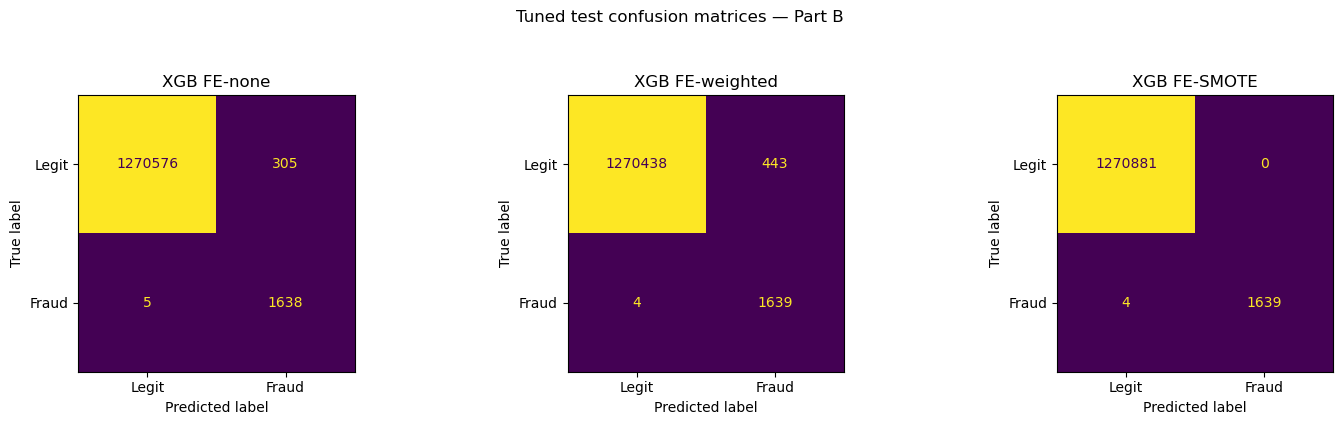

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (cm, title) in zip(axes, [
    (tuned_cm_fe_none,     "XGB FE-none"),
    (tuned_cm_fe_weighted, "XGB FE-weighted"),
    (tuned_cm_fe_smote,    "XGB FE-SMOTE"),
]):
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title)
plt.suptitle("Tuned test confusion matrices — Part B", y=1.05)
plt.tight_layout(); plt.show()


## Threshold analysis - Part B

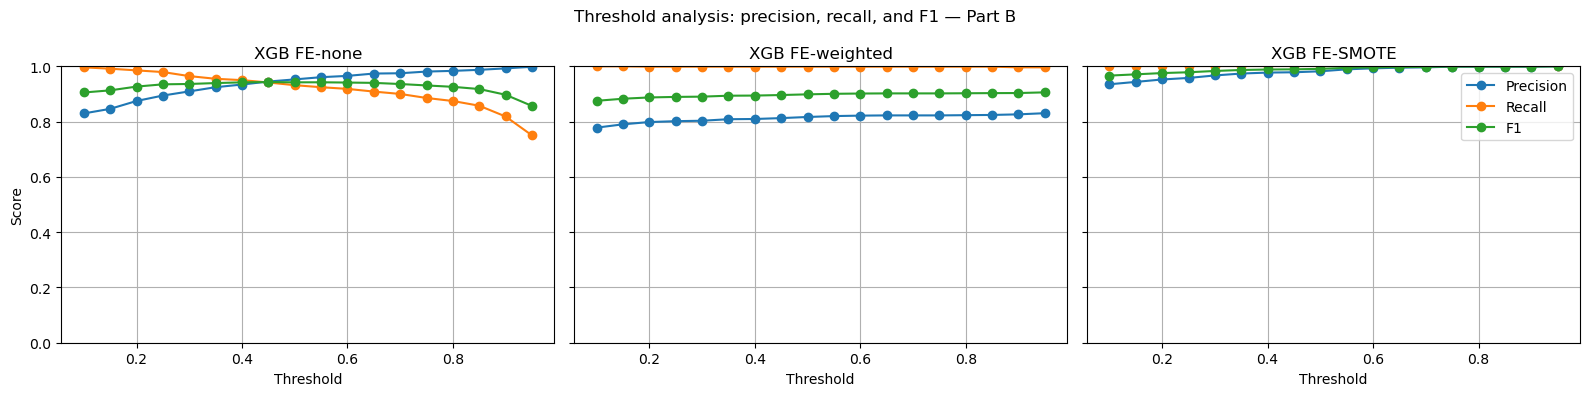

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (df, title) in zip(axes, [
    (threshold_results_fe_none,     "XGB FE-none"),
    (threshold_results_fe_weighted, "XGB FE-weighted"),
    (threshold_results_fe_smote,    "XGB FE-SMOTE"),
]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title); ax.set_xlabel("Threshold"); ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score"); axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, and F1 — Part B")
plt.tight_layout(); plt.show()


## Expected cost by threshold - Part B

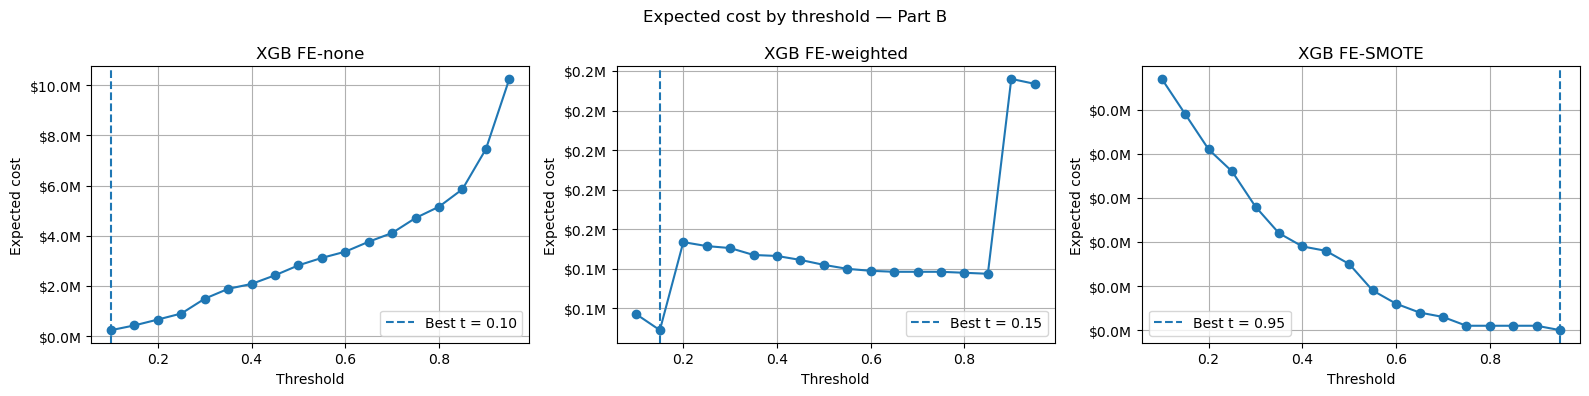

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (df, title) in zip(axes, [
    (cost_df_fe_none,     "XGB FE-none"),
    (cost_df_fe_weighted, "XGB FE-weighted"),
    (cost_df_fe_smote,    "XGB FE-SMOTE"),
]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best t = {best_row['threshold']:.2f}")
    ax.set_title(title); ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold — Part B")
plt.tight_layout(); plt.show()


## Precision-Recall curves - Part B

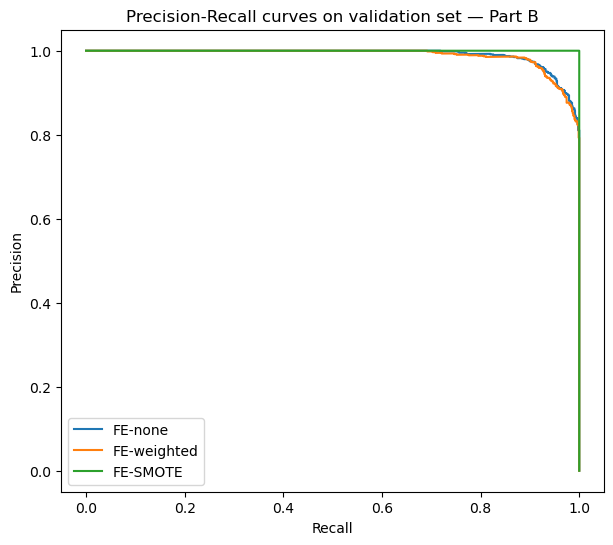

In [90]:
s_fe_none     = model_fe_none.predict_proba(X_val_fe)[:, 1]
s_fe_weighted = model_fe_weighted.predict_proba(X_val_fe)[:, 1]
s_fe_smote    = model_fe_smote.predict_proba(X_val_fe)[:, 1]

p1, r1, _ = precision_recall_curve(y_val_fe, s_fe_none)
p2, r2, _ = precision_recall_curve(y_val_fe, s_fe_weighted)
p3, r3, _ = precision_recall_curve(y_val_fe, s_fe_smote)

plt.figure(figsize=(7, 6))
plt.plot(r1, p1, label="FE-none")
plt.plot(r2, p2, label="FE-weighted")
plt.plot(r3, p3, label="FE-SMOTE")
plt.title("Precision-Recall curves on validation set — Part B")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()


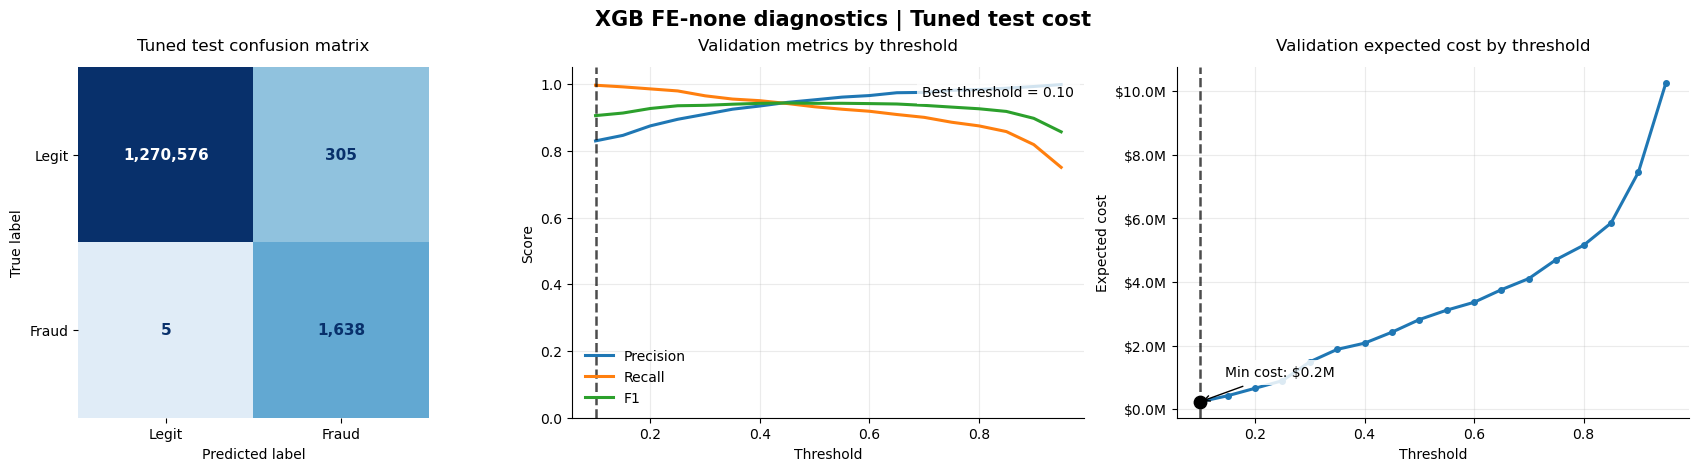

In [91]:
plot_model_diagnostics_pretty(tuned_cm_fe_none, threshold_results_fe_none,
                               cost_df_fe_none, "XGB FE-none")


The diagnostics show that XGB FE-none performs very strongly after threshold tuning. At threshold 0.10, it misses only 5 fraud cases and produces 305 false positives. The cost curve confirms that 0.10 is the best validation threshold. This model is much stronger than the raw-feature XGBoost variants, but it is still slightly worse than FE-SMOTE in expected cost.

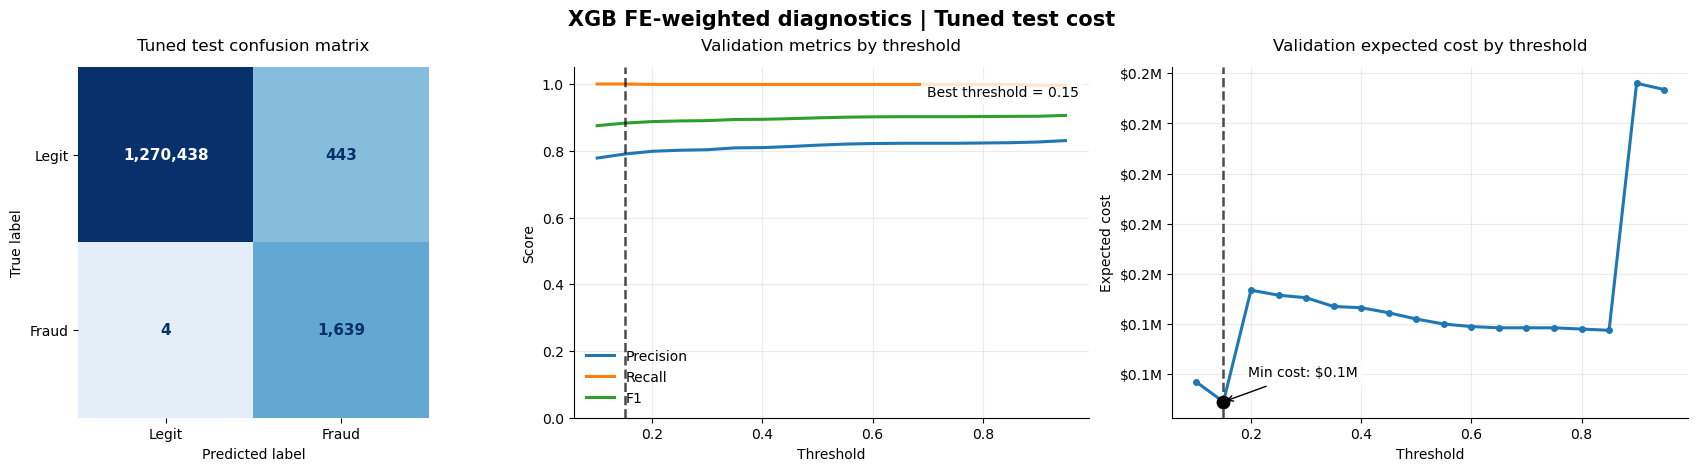

In [92]:
plot_model_diagnostics_pretty(tuned_cm_fe_weighted, threshold_results_fe_weighted,
                               cost_df_fe_weighted, "XGB FE-weighted")


The diagnostics show that XGB FE-weighted detects almost all fraud cases, missing only 4 on the test set. However, it produces 443 false positives, which increases the expected cost. The validation cost curve supports threshold 0.15 as the best choice. 

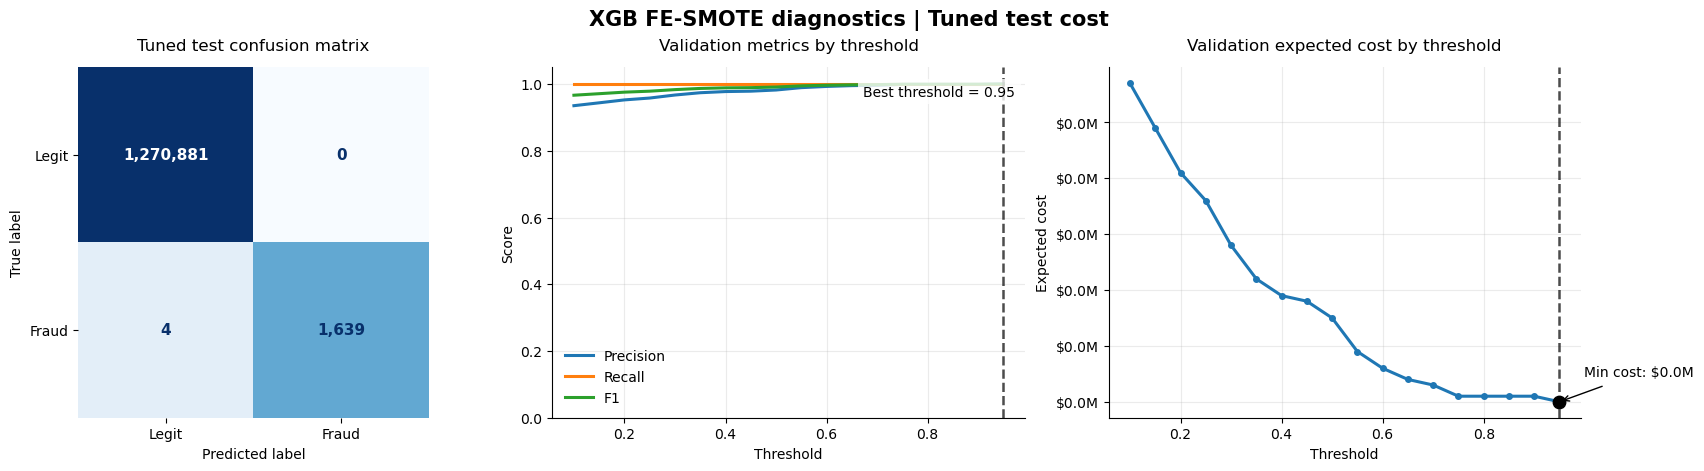

In [93]:
plot_model_diagnostics_pretty(tuned_cm_fe_smote, threshold_results_fe_smote,
                               cost_df_fe_smote, "XGB FE-SMOTE")


The diagnostics show that XGB FE-SMOTE is the strongest feature-engineered model. At threshold 0.95, it misses only 4 fraud cases and produces no false positives on the test set. The validation cost curve supports 0.95 as the best threshold. This model gives the lowest expected cost and the best fraud-detection trade-off.

---
## 9. Combined comparison - Part A vs Part B

All six variants side by side. The key question: how much does feature
engineering improve XGBoost over the raw-feature baseline?


In [94]:
all_variants = pd.concat([comparison_df, comparison_fe_df], ignore_index=True)
all_variants = all_variants.sort_values("tuned_expected_cost").reset_index(drop=True)
all_variants[["model","best_threshold","tuned_test_precision",
              "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,fe_smote,0.95,1.000000,0.997565,0.998781,200000
1,fe_none,0.10,0.843026,0.996957,0.913553,402500
2,fe_weighted,0.15,0.787224,0.997565,0.880000,421500
3,scale_pos_weight,0.80,0.432188,0.987219,0.601186,2115500
4,smote,0.40,0.379036,0.986001,0.547575,2477000
5,none,0.10,0.770143,0.948265,0.849973,4482500


In [95]:
all_variants.to_csv(results_root / "xgboost_fe_vs_nofe_comparison.csv", index=False)
print("Saved to:", results_root / "xgboost_fe_vs_nofe_comparison.csv")


Saved to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgboost_fe_vs_nofe_comparison.csv


## Feature importance - best model

Best model: fe_smote
                feature  importance
     balance_delta_orig    0.506282
    orig_balance_zeroed    0.202055
amount_to_balance_ratio    0.059635
                 type_4    0.057037
         newbalanceOrig    0.054234
         newbalanceDest    0.032289
                 amount    0.023090
                 type_3    0.021223
     balance_delta_dest    0.016377
                 type_1    0.009697
          oldbalanceOrg    0.006585
                   step    0.005126
         isFlaggedFraud    0.003886
         oldbalanceDest    0.001476
                 type_2    0.000575
                 type_0    0.000433


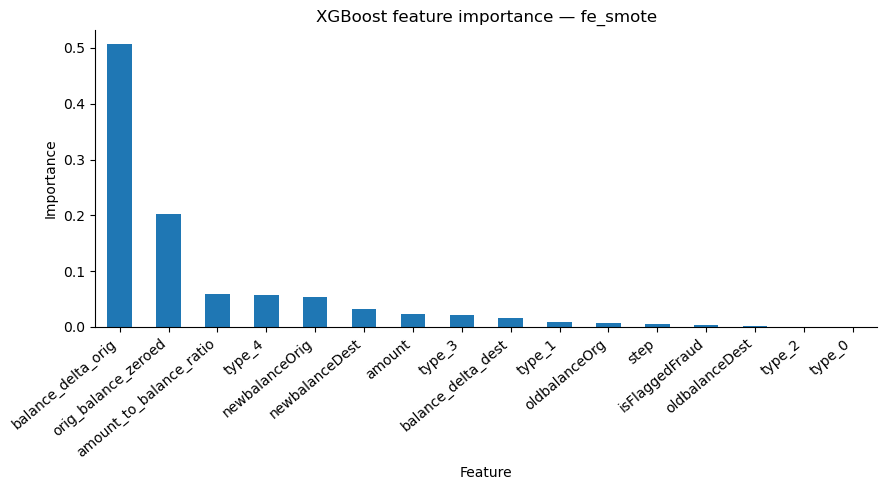

In [96]:
best_model_label = all_variants.iloc[0]["model"]
print("Best model:", best_model_label)

model_lookup = {
    "none": model_none, "scale_pos_weight": model_weighted, "smote": model_smote,
    "fe_none": model_fe_none, "fe_weighted": model_fe_weighted, "fe_smote": model_fe_smote,
}
best_model = model_lookup[best_model_label]

# Get the XGBoost step (key name varies by pipeline type)
xgb_step = best_model.named_steps.get(
    "classifier",
    best_model.named_steps.get("xgbclassifier", None)
)

# Get feature names from the preprocessor (handles OHE expansion)
preprocessor_step = best_model.named_steps.get(
    "preprocessor",
    best_model.named_steps.get("columntransformer", None)
)
try:
    feature_names = preprocessor_step.get_feature_names_out()
    # Strip "num__" / "cat__" prefixes added by ColumnTransformer
    feature_names = [f.split("__")[-1] for f in feature_names]
except Exception:
    # Fallback: use indices if names unavailable
    feature_names = [f"f{i}" for i in range(len(xgb_step.feature_importances_))]

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_step.feature_importances_,
}).sort_values("importance", ascending=False)
print(importance.to_string(index=False))

ax = importance.plot(x="feature", y="importance", kind="bar", figsize=(9, 5), legend=False)
ax.set_title(f"XGBoost feature importance — {best_model_label}")
ax.set_xlabel("Feature"); ax.set_ylabel("Importance")
ax.spines[["top","right"]].set_visible(False)
plt.xticks(rotation=40, ha="right"); plt.tight_layout()
plt.savefig(results_root / "xgboost_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


The feature importance plot shows that the final `fe_smote` model relies mainly on engineered balance-based features. The most important feature is `balance_delta_orig`, followed by `orig_balance_zeroed` and `amount_to_balance_ratio`. This suggests that changes in the sender’s balance and the relationship between transaction amount and account balance are highly informative for fraud detection.

Original features such as `newbalanceOrig`, `newbalanceDest`, and `amount` also contribute, but their importance is lower. 

The plot confirms that feature engineering was very important for improving the XGBoost model.

## Final choice



In [97]:
all_variants.sort_values("tuned_expected_cost")


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
0,fe_smote,0.990947,1.000000,1.000000,0.990632,0.999756,0.998648,0.95,1.000000,0.997565,0.998781,200000
1,fe_none,0.942118,0.999987,0.990648,0.949309,0.999565,0.991117,0.10,0.843026,0.996957,0.913553,402500
2,fe_weighted,0.898630,0.999986,0.989167,0.902782,0.999532,0.989821,0.15,0.787224,0.997565,0.880000,421500
3,scale_pos_weight,0.417409,0.999911,0.957481,0.419070,0.999820,0.960959,0.80,0.432188,0.987219,0.601186,2115500
4,smote,0.614161,0.999913,0.960498,0.617973,0.999766,0.962394,0.40,0.379036,0.986001,0.547575,2477000
5,none,0.885790,0.999917,0.961377,0.893185,0.999789,0.963444,0.10,0.770143,0.948265,0.849973,4482500


Feature engineering clearly improved XGBoost performance compared with the raw-feature models. Among the feature-engineered variants, `fe_smote` achieved the strongest result, with the highest PR-AUC, highest tuned F1-score, and lowest expected cost.

After threshold tuning, `fe_smote` missed only 4 fraud cases and produced no false positives, giving an expected test cost of $200,000. Therefore, `fe_smote` is selected as the final XGBoost model for comparison with the Logistic Regression baseline.